# TAPAS privacy analysis

Five outputs at each of four audit sizes: 50/100, 200/500, 500/1000, 1000/2500 (num_train/num_test).

1. Raw score distributions, member vs non-member
2. Mann-Whitney U test on those scores
3. Classification metrics and effective epsilon with 95% bounds
4. MIA AUC against the null band
5. Privacy-utility tradeoff

Source: `results/sample_size_sweep/`, generated by `audits/run_synthcity_sample_size_sweep.py` (per-fit generator
seeding, `seeds.TAPAS_GENERATOR_SEED_BASE + i`).

### Where things are, and which paper item each section makes

All six generators are audited with one threat model (exact knowledge, black box, 5 MIAs).
Results are read from `results/` by **experiment**, not by script:

| Experiment | Folder | Generators |
|---|---|---|
| Sample-size sweep: ε = 1.0, four audit sizes | `results/sample_size_sweep/{generator}/{stage}/` | BN, PrivBayes, CTGAN, DPGAN, AIM, DP-CTGAN |
| ε sweep: ε = 0.1, 1, 10, 100 at 1000/2500 (ε = 1 is the 1000/2500 stage above) | `results/eps_sweep/{dpgan,aim,dp_ctgan}/` | DPGAN, AIM (no ε = 100), DP-CTGAN |
| Extras | `results/extras/` | DP-CTGAN epoch-cap sweep, DPGAN spike diagnosis, disentangle |

| Section | Paper item |
|---|---|
| 1 Raw score distributions | Fig 2 (`figures/paper/separation_1000_2500.png`); other audit sizes for the sample-size sweep |
| 2 Mann-Whitney | Table 8 (`tables/mannwhitney_*.csv`) |
| 3 Classification metrics and effective ε | Tables 5 and 7 |
| 4-5 AUC bars and privacy-utility trade-off | Fig 1a and 1b (`figures/paper/auc_bar_chart.png`, `privacy_utility_tradeoff.png`). The side-by-side `auc_bar_and_tradeoff.png` used in the paper is not written by any cell here. |
| 6, 6.1-6.3 DPGAN ε sweep and spike diagnosis | Table 6, Appendix A.3 |
| 6.4 DP-CTGAN epoch-cap sweep | extra (not in the paper) |
| 7 AIM | Tables 5-7 |
| 8 Combined radar | extra (not in the paper) |

Figures the paper uses go to `results/figures/paper/`; everything else to `results/figures/supplementary/`.

In [2]:
from pathlib import Path
import sys, glob, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import gaussian_kde, mannwhitneyu

_cwd = Path.cwd()
BENCH = next(c for c in (_cwd, _cwd / "benchmark_tapas", _cwd.parent) if (c / "config.py").exists())
sys.path.insert(0, str(BENCH))
from config import METHODS, METHOD_CONFIG, FIGURES_DIR, UTILITY_RESULTS

SWEEP = BENCH / "results" / "sample_size_sweep"
FIG_PAPER = FIGURES_DIR / "paper"                # figures the paper uses
FIG_SUPP = FIGURES_DIR / "supplementary"         # everything else
for _d in (FIGURES_DIR, FIG_PAPER, FIG_SUPP):
    _d.mkdir(parents=True, exist_ok=True)

STAGES = [(50, 100), (200, 500), (500, 1000), (1000, 2500)]
INK, MUTED, GRID = "#3A3A3A", "#6B6B6B", "#DDDDDD"
# Sections 6 and 7 (the DPGAN and AIM epsilon sweeps) still refer to ORANGE and
# CHARCOAL, the two names the pre-Okabe-Ito palette defined here. They were dropped
# when GEN_COLOR moved to Okabe-Ito but their five call sites were not updated, so
# cells 18, 24, 26, 30 and 34 raised NameError on every run. Restored as aliases onto
# the current palette: CHARCOAL was #3A3A3A, which is exactly INK, and ORANGE was the
# terracotta #CE4E36, whose nearest Okabe-Ito neighbour is Vermillion -- the same
# colour section 1 now uses for the member class. Those sections are single-series
# figures, so neither name collides with a generator hue.
# ROSE is the fourth fidelity series in cell 18; it was the dusty rose #D2B4B1, whose
# Okabe-Ito counterpart is Reddish Purple.
ORANGE, CHARCOAL, ROSE = "#D55E00", INK, "#CC79A7"
SAGE = "#8CA9A0"

# Colorblind-safe (Okabe-Ito) throughout. DP status is carried by shape rather than
# hue -- hatched bars in section 4, hollow markers in section 5 -- so the DP/non-DP
# split survives in greyscale and reads the same way in both figures.
#
# The yellow slot (DP-CTGAN in sections 1-5) is Okabe-Ito #F0E442 DARKENED to #A98600.
# Okabe-Ito is designed for legibility against each other, not against a white ground,
# and #F0E442 has a contrast ratio of 1.32:1 on white -- below the 3:1 WCAG floor for
# graphical objects, and in practice invisible as a thin line or hatch. #A98600 raises
# that to 3.44:1 while staying 40.5 dE from vermillion (CTGAN, the series it must not
# be confused with). A darker olive such as #969900 separates from vermillion further
# still, but closes to 59.5 dE of AIM's bluish green and reads as a second green.
GEN_COLOR = {"bayesian_network": "#0072B2",  # Blue
             "privbayes":        "#56B4E9",  # Sky Blue
             "aim":              "#009E73",  # Bluish Green
             "ctgan":            "#D55E00",  # Vermillion
             "dpgan":            "#A98600"}  # Yellow, darkened -- see below
GEN_DP = {"bayesian_network": False, "privbayes": True, "aim": True,
          "ctgan": False, "dpgan": True, "dpctgan": True}
LABELS = {"bayesian_network": "BN", "privbayes": "PrivBayes",
          "aim": "AIM", "ctgan": "CTGAN", "dpgan": "DPGAN"}
SHORT = {"bayesian_network": "BN", "privbayes": "PrivBayes",
         "aim": "AIM", "ctgan": "CTGAN", "dpgan": "DPGAN"}
ATTACK_ORDER = ["Groundhog", "ShadowModelling", "LocalNeighbourhood",
                "ProbabilityEstimation", "ClosestDistance"]
SHORT_ATK = {"Groundhog": "Groundhog", "ShadowModelling": "ShadowMod.",
             "LocalNeighbourhood": "LocalNbr.", "ProbabilityEstimation": "ProbabilityEst.",
             "ClosestDistance": "ClosestDist."}
SCORE_LABEL = {"Groundhog": "RF P(member)", "ShadowModelling": "RF P(member)",
               "LocalNeighbourhood": "fraction of records in radius",
               "ProbabilityEstimation": "KDE log-density at target",
               "ClosestDistance": "negative min L2 distance"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.facecolor": "white", "font.size": 10,
                     "hatch.linewidth": .8})


def null_halfwidth(n1, n2):
    """Half-width of the 95% band around AUC=0.5 under H0. Depends on num_test, so it
    is recomputed at every stage: +-0.114 at num_test=100 down to +-0.023 at 2500."""
    return 1.96 * np.sqrt((n1 + n2 + 1) / (12 * n1 * n2))


def density(v, grid):
    v = np.asarray(v)
    if len(np.unique(v)) < 3 or np.std(v) == 0:
        return None
    try:
        return gaussian_kde(v)(grid)
    except np.linalg.LinAlgError:
        return None


def tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=10, length=3)
    ax.set_axisbelow(True)


# ---- load every stage ----
SCORES, METRICS = {}, {}
for ntr, nte in STAGES:
    st = f"{ntr}_{nte}"
    s = [pd.read_csv(f) for f in sorted(glob.glob(str(SWEEP / f"raw_scores_*_{st}.csv")))]
    m = [pd.read_csv(f) for f in sorted(glob.glob(str(SWEEP / "*" / st / f"effeps_*_{st}.csv")))]
    if not s or not m:
        continue
    sd = pd.concat(s, ignore_index=True); sd["attack_short"] = sd.attack.str.split("(").str[0]
    md_ = pd.concat(m, ignore_index=True); md_["attack_short"] = md_.attack.str.split("(").str[0]
    SCORES[st], METRICS[st] = sd, md_

AVAIL = [(a, b) for a, b in STAGES if f"{a}_{b}" in SCORES]
GENS = [g for g in METHODS if g in set(SCORES[f"{AVAIL[0][0]}_{AVAIL[0][1]}"].generator)]
BANDS = {f"{a}_{b}": null_halfwidth(b // 2, b // 2) for a, b in AVAIL}

for a, b in AVAIL:
    st = f"{a}_{b}"
    print(f"{st:>10}: {len(SCORES[st]):6,} score rows | {SCORES[st].generator.nunique()} generators "
          f"| null band +-{BANDS[st]:.3f}")

    50_100:  2,000 score rows | 4 generators | null band +-0.114
   200_500: 10,000 score rows | 4 generators | null band +-0.051
  500_1000: 20,000 score rows | 4 generators | null band +-0.036
 1000_2500: 50,000 score rows | 4 generators | null band +-0.023


In [3]:
# ---- sections 1-5 report ONE audit size: 1000/2500 at formal eps = 1.0 ----
# Sections 1-5 all iterate AVAIL, so pinning it here scopes every figure and table in
# them at once. Section 7 iterates STAGES instead and is untouched, so AIM keeps its
# full counts curve there.
#
# WHY ONLY 1000/2500. DP-CTGAN has exactly one valid audit size. Its counts sweep was
# run against the spike diagnosis's already-complete 3500-fit pool, and TAPAS returns
# the WHOLE memoised pool rather than a prefix -- so the 50/100, 200/500 and 500/1000
# directories hold copies of the 1000/2500 result under different labels. Only the
# 1000/2500 stage is a real measurement there, because pool size == stage size. (The
# merge cell below still guards against the degenerate case; with a single stage there
# is nothing to cross-check, which is why the restriction comes first.)
#
# It is also the right row on its own merits: 1000/2500 is where every other
# generator's headline number lives, and where the bound resolves at all. In the
# committed counts sweep all four Synthcity methods returned eps_low_95 = 0 at 50/100
# with the max-AUC ordering inverted (BN 0.595 above DPGAN 0.584); only by 1000/2500 do
# the GANs separate. So this is the row to report, not a fallback.
FOCUS = (1000, 2500)
if FOCUS in AVAIL:
    AVAIL = [FOCUS]
    print(f"sections 1-5 restricted to {FOCUS[0]}/{FOCUS[1]}, formal eps = 1.0")
else:
    print(f"{FOCUS} not loaded -- sections 1-5 keep {AVAIL}")


sections 1-5 restricted to 1000/2500, formal eps = 1.0


In [4]:
# ---- merge the AIM audit in as a fifth generator ----
# ADDITIVE ONLY. Nothing about the existing four generators changes: their scores,
# metrics, colours and labels are untouched, and AIM is appended to the same SCORES /
# METRICS dicts sections 1-5 already read. Re-run sections 1-5 after this cell and
# AIM appears in the score distributions, the Mann-Whitney table, the metrics table,
# the AUC bars and the tradeoff scatter.
#
# AIM's audit lives in results/sample_size_sweep/aim/{stage}/ alongside the Synthcity
# generators, but was run by a separate script (benchmark_tapas/audits/run_aim_audit.py) against a
# generator that is not a Synthcity plugin. Same threat model though -- same fixed
# background, same target/alternate, same 5-attack battery, same counts -- which is
# what makes appending it legitimate rather than a category error.
#
# ALL-OR-NOTHING BY DESIGN. GENS is built once from the first stage and reused for
# every stage, so a generator present at some stages and absent at others would reach
# mannwhitneyu() with empty arrays. Rather than special-case that, the merge waits
# until AIM covers every stage in AVAIL.

AIM_DIR = BENCH / "results" / "sample_size_sweep" / "aim"
AIM_COLOR = GEN_COLOR["aim"]  # Okabe-Ito bluish green, set with the rest of the palette
AIM_LABEL, AIM_SHORT = "AIM (DP)", "AIM"

_aim_have = {f"{a}_{b}" for a, b in AVAIL
             if (AIM_DIR / f"{a}_{b}" / f"effeps_aim_{a}_{b}.csv").exists()}
_aim_want = {f"{a}_{b}" for a, b in AVAIL}
_already = any("aim" in set(SCORES[st].generator) for st in _aim_want)

if _already:
    print("AIM already merged (cell re-run) -- nothing to do")
elif not _aim_have:
    print(f"no AIM audit found under {AIM_DIR.relative_to(BENCH)}/\n"
          "  run: python benchmark_tapas/audits/run_aim_audit.py")
elif _aim_have != _aim_want:
    print(f"AIM has {sorted(_aim_have)}; sections 1-5 also need "
          f"{sorted(_aim_want - _aim_have)}.\n"
          "  Merge skipped: GENS is global across stages, so a partially-present\n"
          "  generator would reach the Mann-Whitney cell with empty arrays.\n"
          "  Re-run this cell once the remaining stages finish and are rsync'd.")
else:
    for a, b in AVAIL:
        st = f"{a}_{b}"
        s = pd.read_csv(AIM_DIR / st / f"raw_scores_aim_{a}_{b}.csv")
        s["attack_short"] = s.attack.str.split("(").str[0]
        m = pd.read_csv(AIM_DIR / st / f"effeps_aim_{a}_{b}.csv")
        m["attack_short"] = m.attack.str.split("(").str[0]
        # AIM's metrics table carries three extra columns (delta, tn, fn); concat
        # leaves them NaN for the other four, and the display cells select explicitly.
        SCORES[st] = pd.concat([SCORES[st], s], ignore_index=True)
        METRICS[st] = pd.concat([METRICS[st], m], ignore_index=True)

    GENS = GENS + ["aim"]
    GEN_COLOR["aim"] = AIM_COLOR
    LABELS["aim"] = AIM_LABEL
    SHORT["aim"] = AIM_SHORT
    # The tradeoff cell reads dp/kind from METHOD_CONFIG. AIM is not in the imported
    # config (it is not a Synthcity plugin), so add the entry in memory only --
    # benchmark_tapas/config.py itself is left exactly as the other results were run under.
    METHOD_CONFIG.setdefault("aim", {"dp": True, "kind": "statistical",
                                     "plugin_kwargs": {}})

    print(f"merged AIM across {len(AVAIL)} stages -> generators now: "
          f"{', '.join(SHORT[g] for g in GENS)}")
    for a, b in AVAIL:
        st = f"{a}_{b}"
        n = int((SCORES[st].generator == "aim").sum())
        print(f"  {st:>10}: +{n:,} AIM score rows "
              f"({len(SCORES[st]):,} total, {SCORES[st].generator.nunique()} generators)")
    print("\nNote: AIM is audited at eps=1.0 with delta=1e-9 (natively zCDP, rho=0.0150),")
    print("while PrivBayes is pure DP (delta=0) and DPGAN derives delta=1/n = 2e-3 on the")
    print("500-row audit background. Same nominal eps, three different guarantees.")


merged AIM across 1 stages -> generators now: BN, PrivBayes, CTGAN, DPGAN, AIM
   1000_2500: +12,500 AIM score rows (62,500 total, 5 generators)

Note: AIM is audited at eps=1.0 with delta=1e-9 (natively zCDP, rho=0.0150),
while PrivBayes is pure DP (delta=0) and DPGAN derives delta=1/n = 2e-3 on the
500-row audit background. Same nominal eps, three different guarantees.


In [5]:
# ---- merge the DP-CTGAN counts sweep in as a sixth generator ----
# ADDITIVE ONLY, exactly as the AIM merge above. Nothing about the existing five
# generators changes; DP-CTGAN is appended to the same SCORES / METRICS dicts that
# sections 1-5 already read, so re-running those sections picks it up in the score
# distributions, the Mann-Whitney table, the metrics table, the AUC bars and the
# tradeoff scatter.
#
# Its audit lives in results/sample_size_sweep/dp_ctgan/{stage}/ alongside the Synthcity
# generators, but was run by benchmark_tapas/audits/run_dpctgan_audit.py against a
# generator that is not a Synthcity plugin. Same threat model as everything else --
# same fixed background (TAPAS_BG_SEED), same target/alternate (TAPAS_TARGET_SEED),
# same 5-attack battery under the same SCORE_ATTACK_SEED, 500 records per simulation,
# same four stages -- which is what makes appending it legitimate.
#
# ALL-OR-NOTHING, for the same reason as AIM: GENS is global across stages, so a
# generator present at some stages and missing at others reaches mannwhitneyu() with
# empty arrays.

DPC_DIR = BENCH / "results" / "sample_size_sweep" / "dp_ctgan"
DPC_COLOR = GEN_COLOR["dpgan"]  # Okabe-Ito yellow: DP-CTGAN is the neural DP method
                                # reported in sections 1-5, so it takes that slot
DPC_LABEL, DPC_SHORT = "DP-CTGAN (DP)", "DP-CTGAN"

def _dpc_degenerate() -> bool:
    """True if every stage's metrics are identical -- i.e. all scored on one pool.

    A real counts sweep moves: the Synthcity generators' AUCs change stage to stage as
    the sample grows. Identical rows across four stages cannot happen by chance and
    always mean the pool was already larger than the stage (see the note in the
    refusal message below). Checked rather than assumed, because the failure is silent
    at every layer beneath this one -- the CSVs are well-formed and correctly named.
    """
    sig = set()
    for a, b in AVAIL:
        d = pd.read_csv(DPC_DIR / f"{a}_{b}" / f"effeps_dpctgan_{a}_{b}.csv")
        sig.add(tuple(d.sort_values("attack").auc.round(9)))
    return len(sig) == 1 and len(AVAIL) > 1


_dpc_have = {f"{a}_{b}" for a, b in AVAIL
             if (DPC_DIR / f"{a}_{b}" / f"effeps_dpctgan_{a}_{b}.csv").exists()}
_dpc_want = {f"{a}_{b}" for a, b in AVAIL}
_dpc_already = any("dpctgan" in set(SCORES[st].generator) for st in _dpc_want)

if _dpc_already:
    print("DP-CTGAN already merged (cell re-run) -- nothing to do")
elif not _dpc_have:
    print(f"no DP-CTGAN audit found under {DPC_DIR.relative_to(BENCH)}/\n"
          "  run: python benchmark_tapas/audits/run_dpctgan_audit.py "
          "--num-train 50 --num-test 100   (and the other three stages)")
elif _dpc_have != _dpc_want:
    print(f"DP-CTGAN has {sorted(_dpc_have)}; sections 1-5 also need "
          f"{sorted(_dpc_want - _dpc_have)}.\n"
          "  Merge skipped -- see the all-or-nothing note above.")
elif _dpc_degenerate():
    print("DP-CTGAN counts sweep is DEGENERATE -- merge refused.\n"
          "  Every stage returned identical metrics, which means the attacks were all\n"
          "  scored on the same pool. TAPAS does not truncate: _generate_samples\n"
          "  subtracts what is memoised, generates the shortfall, and returns the WHOLE\n"
          "  memory -- so a stage asking for 100 test datasets against a pool of 2500 is\n"
          "  scored on 2500 and labelled 100.\n"
          "  run_synthcity_sample_size_sweep.py is correct because it walks its stages upward on a FRESH\n"
          "  pool. This sweep instead reused the spike diagnosis's completed 3500-fit\n"
          "  cache/dpctgan_eps1, so all four stages are copies of 1000/2500.\n"
          "  Fix: re-run with its own empty pool --\n"
          "    for s in '50 100' '200 500' '500 1000' '1000 2500'; do\n"
          "      python benchmark_tapas/audits/run_dpctgan_audit.py \\\n"
          "             --num-train ${s% *} --num-test ${s#* } --cache-tag counts\n"
          "    done")
else:
    for a, b in AVAIL:
        st = f"{a}_{b}"
        s = pd.read_csv(DPC_DIR / st / f"raw_scores_dpctgan_{a}_{b}.csv")
        s["attack_short"] = s.attack.str.split("(").str[0]
        m = pd.read_csv(DPC_DIR / st / f"effeps_dpctgan_{a}_{b}.csv")
        m["attack_short"] = m.attack.str.split("(").str[0]
        # DP-CTGAN's metrics table carries sigma / epochs_cap / batch_size / library
        # on top of AIM's extras; concat leaves them NaN elsewhere and the display
        # cells select columns explicitly.
        SCORES[st] = pd.concat([SCORES[st], s], ignore_index=True)
        METRICS[st] = pd.concat([METRICS[st], m], ignore_index=True)

    GENS = GENS + ["dpctgan"]
    GEN_COLOR["dpctgan"] = DPC_COLOR
    LABELS["dpctgan"] = DPC_LABEL
    SHORT["dpctgan"] = DPC_SHORT
    METHOD_CONFIG.setdefault("dpctgan", {"dp": True, "kind": "neural",
                                         "plugin_kwargs": {}})

    print(f"merged DP-CTGAN across {len(AVAIL)} stages -> generators now: "
          f"{', '.join(SHORT[g] for g in GENS)}")
    for a, b in AVAIL:
        st = f"{a}_{b}"
        n = int((SCORES[st].generator == "dpctgan").sum())
        print(f"  {st:>10}: +{n:,} DP-CTGAN score rows "
              f"({len(SCORES[st]):,} total, {SCORES[st].generator.nunique()} generators)")

    # The single most important caveat for reading DP-CTGAN next to the others.
    _spent = None
    _meta = DPC_DIR / f"{AVAIL[-1][0]}_{AVAIL[-1][1]}" / "meta.json"
    if _meta.exists():
        _spent = json.loads(_meta.read_text()).get("last_epsilon_spent")
    print("\nNOTE: epsilon means something different for DP-CTGAN. SmartNoise fixes")
    print("sigma=5 and treats eps as a STOPPING RULE -- it trains until the accountant")
    print("says the budget is spent, then breaks. On the 500-row audit background")
    print("batch_size=500 gives sampling rate 1.0, so there is NO amplification and the")
    print("budget dies after 3 epochs" + (f", having spent eps={_spent:.3f}" if _spent else "") + ".")
    print("So the formal bound to read these numbers against is that SPENT value, not")
    print("the nominal 1.0 -- and the generator under audit is a 3-epoch network.")
    print("delta also differs across the DP methods: PrivBayes 0 (pure DP), AIM 1e-9,")
    print("DPGAN 1/n = 2e-3, DP-CTGAN 1/(n*sqrt(n)) = 8.9e-5 on this background.")


merged DP-CTGAN across 1 stages -> generators now: BN, PrivBayes, CTGAN, DPGAN, AIM, DP-CTGAN
   1000_2500: +12,500 DP-CTGAN score rows (75,000 total, 6 generators)

NOTE: epsilon means something different for DP-CTGAN. SmartNoise fixes
sigma=5 and treats eps as a STOPPING RULE -- it trains until the accountant
says the budget is spent, then breaks. On the 500-row audit background
batch_size=500 gives sampling rate 1.0, so there is NO amplification and the
budget dies after 3 epochs, having spent eps=1.473.
So the formal bound to read these numbers against is that SPENT value, not
the nominal 1.0 -- and the generator under audit is a 3-epoch network.
delta also differs across the DP methods: PrivBayes 0 (pure DP), AIM 1e-9,
DPGAN 1/n = 2e-3, DP-CTGAN 1/(n*sqrt(n)) = 8.9e-5 on this background.


In [6]:
# ---- display order for sections 1-5 ----
# Every figure and table in sections 1-5 iterates GENS, so setting it once here fixes
# both the order and the membership for all of them.
#
# synthcity's DPGAN is REMOVED from this comparison -- DP-CTGAN is the neural DP method
# reported. Nothing is deleted: its rows stay in SCORES/METRICS, and section 6 is
# entirely unaffected because that section is DPGAN's own epsilon sweep and reads its
# EPS tables rather than GENS.
#
# The order pairs each DP method with its non-DP counterpart inside a family --
# statistical first (BN no-DP, PrivBayes DP, AIM DP), then neural (CTGAN no-DP,
# DP-CTGAN DP). It matches PLOT_ORDER in evaluation/fidelity_utility_analysis.ipynb, so the fidelity,
# utility and privacy figures all read left to right in the same sequence.
PLOT_ORDER = ["bayesian_network", "privbayes", "aim", "ctgan", "dpctgan"]

_dropped = [g for g in GENS if g not in PLOT_ORDER]
GENS = [g for g in PLOT_ORDER if g in GENS]

print("sections 1-5 show:", ", ".join(SHORT[g] for g in GENS))
if _dropped:
    print("removed from the comparison:", ", ".join(SHORT[g] for g in _dropped))
_absent = [g for g in PLOT_ORDER if g not in GENS]
if _absent:
    print(f"not merged, so absent: {', '.join(_absent)}"
          "  (see the merge cells above for why)")


sections 1-5 show: BN, PrivBayes, AIM, CTGAN, DP-CTGAN
removed from the comparison: DPGAN


## 1. Raw score distributions

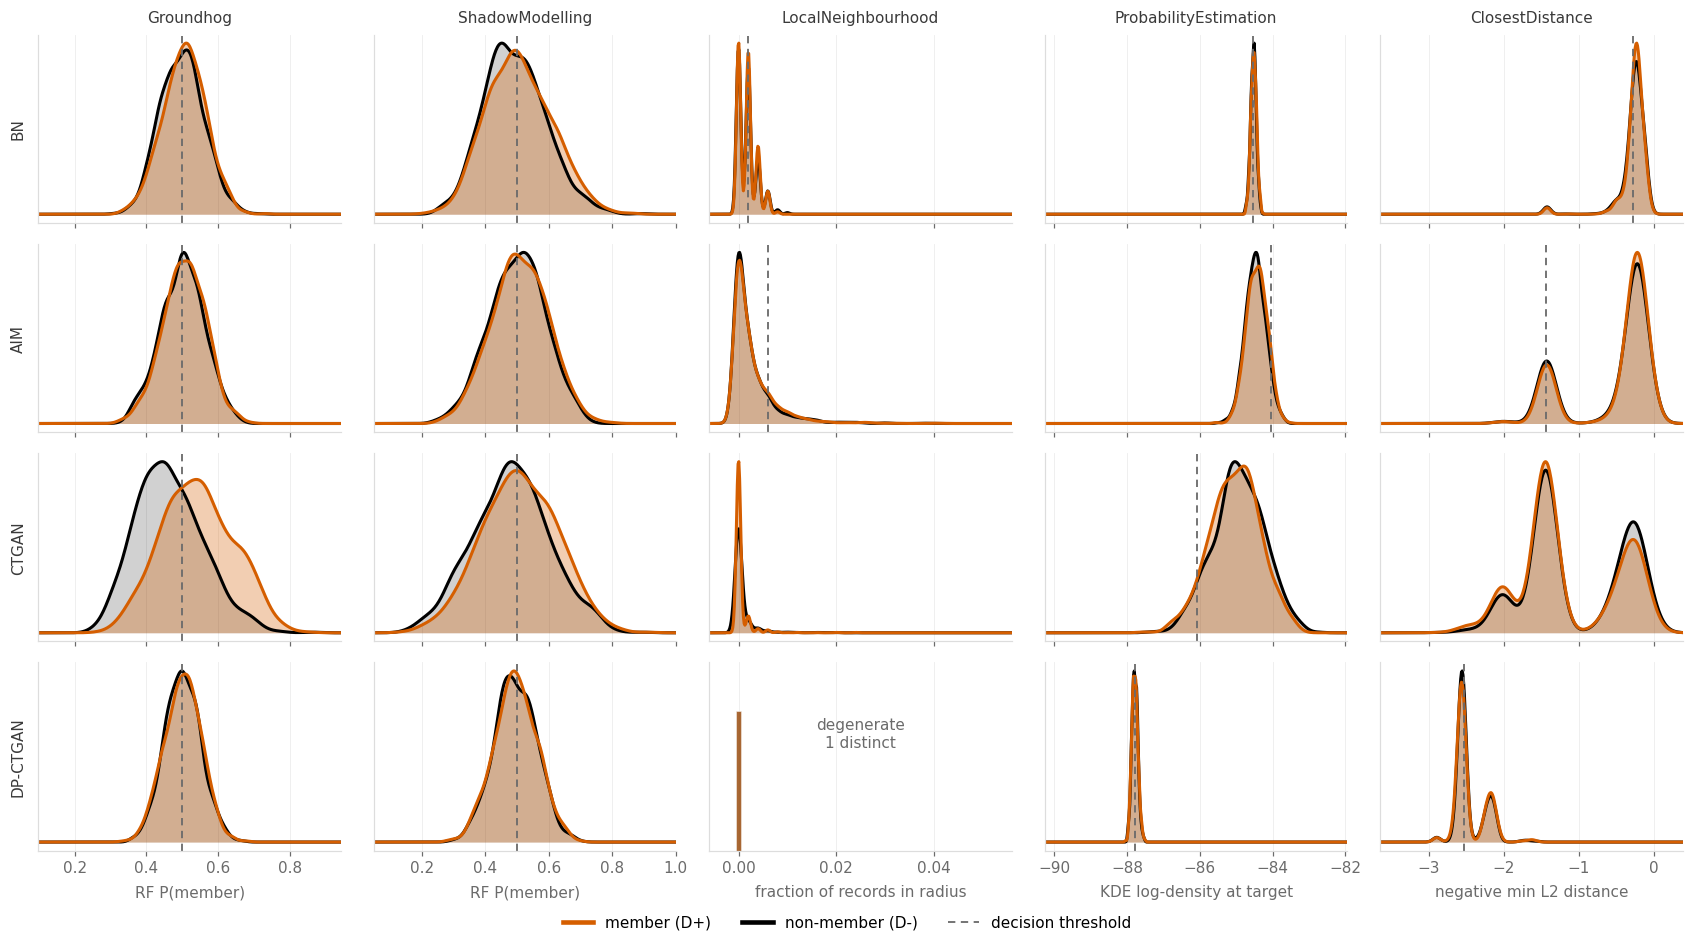

In [7]:
# These panels contrast two CLASSES, not five generators, so they carry their own two
# colours rather than anything from GEN_COLOR. This also repairs the cell: it used to
# reference ORANGE and CHARCOAL, which cell 1 dropped when the palette moved to
# Okabe-Ito, so section 1 raised NameError on every run.
MEMBER, NONMEMBER = "#D55E00", "#000000"      # Okabe-Ito Vermillion / Black

# GENS_DIST, not GENS: PrivBayes is dropped from this matrix only, scoped locally like
# the bar chart's GENS_BAR and the scatter's GENS_SCATTER -- sections 2-3 (Mann-Whitney,
# classification metrics) still show it.
GENS_DIST = [g for g in GENS if g != "privbayes"]

for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"
    sc = SCORES[st]
    attacks = [a for a in ATTACK_ORDER if a in set(sc.attack_short)]
    fig, axes = plt.subplots(len(GENS_DIST), len(attacks), sharex="col",
                             figsize=(3.1 * len(attacks), 2.15 * len(GENS_DIST)), squeeze=False)
    for c, atk in enumerate(attacks):
        sub = sc[sc.attack_short == atk]
        lo, hi = sub.raw_score.min(), sub.raw_score.max()
        pad = (hi - lo) * 0.12 if hi > lo else 0.5
        grid = np.linspace(lo - pad, hi + pad, 400)
        for r, gen in enumerate(GENS_DIST):
            ax = axes[r][c]
            g = sub[sub.generator == gen]
            mem = g[g.ground_truth == 1].raw_score.values
            non = g[g.ground_truth == 0].raw_score.values
            dm, dn = density(mem, grid), density(non, grid)
            if dm is None or dn is None:
                w = (grid[-1] - grid[0]) / 60
                for vals, col in ((non, NONMEMBER), (mem, MEMBER)):
                    u, cts = np.unique(vals, return_counts=True)
                    ax.bar(u, cts / cts.sum(), width=w, color=col, alpha=.55,
                           edgecolor="white", lw=.5)
                ax.set_ylim(0, 1.35)
                ax.text(.5, .55, f"degenerate\n{g.raw_score.nunique()} distinct",
                        transform=ax.transAxes, ha="center", fontsize=10, color=MUTED)
            else:
                ax.fill_between(grid, dn, color=NONMEMBER, alpha=.18, lw=0)
                ax.fill_between(grid, dm, color=MEMBER, alpha=.30, lw=0)
                ax.plot(grid, dn, color=NONMEMBER, lw=2)
                ax.plot(grid, dm, color=MEMBER, lw=2)
            thr = g.threshold.iloc[0]
            if np.isfinite(thr) and grid[0] <= thr <= grid[-1]:
                ax.axvline(thr, color=MUTED, ls=(0, (4, 3)), lw=1.2)
            ax.set_xlim(grid[0], grid[-1]); ax.set_yticks([]); tidy(ax)
            ax.grid(axis="x", color=GRID, lw=.6, alpha=.5)
            if r == 0: ax.set_title(atk, fontsize=10, color=INK, pad=8)
            if c == 0: ax.set_ylabel(SHORT[gen], fontsize=10, color=INK, labelpad=8)
            if r == len(GENS_DIST) - 1:
                ax.set_xlabel(SCORE_LABEL.get(atk, "score"), fontsize=10, color=MUTED, labelpad=6)
    fig.legend(handles=[Line2D([], [], color=MEMBER, lw=3, label="member (D+)"),
                        Line2D([], [], color=NONMEMBER, lw=3, label="non-member (D-)"),
                        Line2D([], [], color=MUTED, ls=(0, (4, 3)), lw=1.2, label="decision threshold")],
               loc="lower center", ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(.5, -.004))
    fig.tight_layout(rect=[0, .025, 1, 1])
    fig.savefig(FIG_PAPER / f"separation_{st}.png", bbox_inches="tight")
    plt.show()

## 2. Mann-Whitney U test

Two-sided, tie-corrected. H0: member and non-member raw scores share a distribution.

In [8]:
from config import TABLES_DIR

ALPHA = 0.05
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MW = {}
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"; sc = SCORES[st]
    rows = []
    for gen in GENS:
        for atk in [a for a in ATTACK_ORDER if a in set(sc.attack_short)]:
            cell = sc[(sc.generator == gen) & (sc.attack_short == atk)]
            m = cell[cell.ground_truth == 1].raw_score.values
            n = cell[cell.ground_truth == 0].raw_score.values
            U, p = mannwhitneyu(m, n, alternative="two-sided")
            # U and the two group sizes are carried through to the CSV, not just p and
            # auc: auc = U/(n_member*n_nonmember) is only reproducible from the file if
            # the denominator is in it, and a reader checking the test needs U itself.
            rows.append(dict(generator=SHORT[gen], attack=atk, p=p,
                             auc=U / (len(m) * len(n)), U=U,
                             n_member=len(m), n_nonmember=len(n)))
    MW[st] = pd.DataFrame(rows)
    tbl = MW[st].pivot(index="generator", columns="attack", values="p")
    tbl = tbl.reindex(index=[SHORT[g] for g in GENS],
                      columns=[a for a in ATTACK_ORDER if a in tbl.columns])
    n_sig = int((MW[st].p < ALPHA).sum())
    print(f"\n=== {ntr}/{nte} ===   significant at p<{ALPHA}: {n_sig} of {len(MW[st])}"
          f"   (Bonferroni {ALPHA}/{len(MW[st])} = {ALPHA/len(MW[st]):.4f}: "
          f"{int((MW[st].p < ALPHA/len(MW[st])).sum())})")
    print(tbl.round(4).to_string())

    # Long form, one row per generator x attack, with both significance verdicts
    # resolved in the file. The Bonferroni threshold depends on how many tests this
    # stage ran, so recording the flag beside the alpha it used keeps the CSV readable
    # on its own -- 25 tests here, but that changes with the generator list.
    _bonf = ALPHA / len(MW[st])
    _out = MW[st].assign(num_train=ntr, num_test=nte, formal_epsilon=1.0,
                         alpha=ALPHA, significant=MW[st].p < ALPHA,
                         bonferroni_alpha=_bonf,
                         significant_bonferroni=MW[st].p < _bonf)
    _out = _out[["generator", "attack", "num_train", "num_test", "formal_epsilon",
                 "n_member", "n_nonmember", "U", "auc", "p",
                 "alpha", "significant", "bonferroni_alpha", "significant_bonferroni"]]
    _path = TABLES_DIR / f"mannwhitney_{st}.csv"
    _out.to_csv(_path, index=False)
    print(f"\nwrote {_path.relative_to(BENCH)} ({len(_out)} rows)")


=== 1000/2500 ===   significant at p<0.05: 10 of 25   (Bonferroni 0.05/25 = 0.0020: 5)
attack     Groundhog  ShadowModelling  LocalNeighbourhood  ProbabilityEstimation  ClosestDistance
generator                                                                                        
BN            0.0023           0.0007              0.6374                 0.0399           0.3709
PrivBayes     0.2718           0.1078              0.8180                 0.9414           0.8038
AIM           0.0502           0.0427              0.2124                 0.0055           0.1529
CTGAN         0.0000           0.0000              0.0171                 0.0007           0.0000
DP-CTGAN      0.4722           0.7638              1.0000                 0.9519           0.3134

wrote results/tables/mannwhitney_1000_2500.csv (25 rows)


## 3. Classification metrics and effective epsilon

In [9]:
COLS = ["auc", "tp", "fp", "mia_advantage", "privacy_gain",
        "eff_epsilon_pointwise", "eps_low_95", "eps_high_95"]
for ntr, nte in AVAIL:
    st = f"{ntr}_{nte}"; m = METRICS[st].copy()
    # Filter as well as sort: this cell prints METRICS wholesale, so a generator
    # dropped from GENS would otherwise still appear here (with a NaN sort key).
    m = m[m.method.isin(GENS)]
    m["generator"] = m.method.map(SHORT)
    m = m.sort_values(["method", "attack_short"],
                      key=lambda s: s.map({g: i for i, g in enumerate(GENS)}) if s.name == "method" else s)
    out = m[["generator", "attack_short"] + [c for c in COLS if c in m]]
    out = out.rename(columns={"attack_short": "attack", "mia_advantage": "advantage",
                              "eff_epsilon_pointwise": "eps_point",
                              "eps_low_95": "eps_lo95", "eps_high_95": "eps_hi95"})
    print(f"\n=== {ntr}/{nte} ===")
    print(out.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


=== 1000/2500 ===
generator                attack    auc     tp     fp  advantage  privacy_gain  eps_point  eps_lo95  eps_hi95
       BN       ClosestDistance 0.5103 0.6736 0.6360     0.0376        0.9624     0.6931    0.0000    0.0115
       BN             Groundhog 0.5352 0.5152 0.4632     0.0520        0.9480     0.2647    0.0000    0.0075
       BN    LocalNeighbourhood 0.5051 0.5984 0.5840     0.0144        0.9856     0.0244    0.0000    0.0039
       BN ProbabilityEstimation 0.5237 0.6336 0.6072     0.0264        0.9736     2.1972    0.0000    0.0114
       BN       ShadowModelling 0.5393 0.4840 0.4424     0.0416        0.9584     0.5173    0.0000    0.0035
PrivBayes       ClosestDistance 0.4971 0.7192 0.7232    -0.0040        1.0040     0.6931    0.0000    0.0156
PrivBayes             Groundhog 0.4873 0.4512 0.4744    -0.0232        1.0232     0.0870    0.0000    0.0079
PrivBayes    LocalNeighbourhood 0.4989 0.0000 0.0000     0.0000        1.0000     0.5390    0.0000    0.0039


## 4. MIA AUC against the null band

Band width depends on num_test, so it narrows at every stage.

**Reading the band.** The grey band is the 95% interval for the AUC statistic under
H0: member and non-member scores are exchangeable (no separation) -- the standard
normal-approximation variance of the Mann-Whitney U statistic, `null_halfwidth()` in
cell 1. The dashed centre line is the theoretical H0 value, AUC=0.5 (not an estimated
mean of anything). A dot marks a bar whose AUC falls outside that interval: evidence
against H0, i.e. detectable separation; no dot means the result is consistent with no
separation.

This band uses a FIXED half-width (same for every attack within a stage, since it only
depends on num_test), which is close to but not identical to the exact per-attack
Mann-Whitney test in `results/tables/mannwhitney_1000_2500.csv` (section 2) -- that
test tie-corrects, this band does not. They agree on 24 of 25 cells at 1000/2500;
CTGAN/LocalNeighbourhood is the exception (AUC=0.483, inside the band here, but
p=0.017 in the exact test) -- LocalNeighbourhood's score is heavily tied (many exact
zeros), which the exact test corrects for and the fixed band does not. Treat the dots
here as a visual guide, and the CSV as the number to cite.

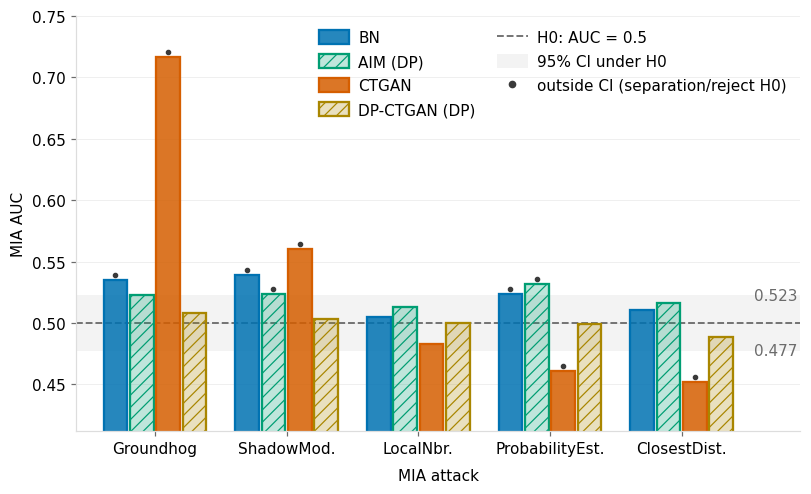

In [10]:
GENS_BAR = [g for g in GENS if g != "privbayes"]  # dropped from this figure and the
                                                   # tradeoff scatter; sections 1-3 keep it
BLACK = "#000000"

allauc = pd.concat([MW[f"{a}_{b}"].assign(stage=f"{a}/{b}") for a, b in AVAIL])
# A FIXED cap, not headroom derived from the tallest bar. The legend sits in the upper
# RIGHT, and the only bar tall enough to reach that band -- CTGAN on Groundhog, 0.717 --
# is in the leftmost group, so the reserve never had to clear it. Capping at 0.75 gives
# that vertical space back rather than reserving headroom no bar needs.
YMAX = .75
ylo, yhi = allauc.auc.min() - .04, YMAX
if allauc.auc.max() > YMAX:
    print(f"WARNING: max AUC {allauc.auc.max():.3f} exceeds YMAX={YMAX} -- bars clipped")

ncol = 2 if len(AVAIL) > 1 else 1
nrow = int(np.ceil(len(AVAIL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7.5 * ncol, 4.6 * nrow), squeeze=False)
for k, (ntr, nte) in enumerate(AVAIL):
    ax = axes[k // ncol][k % ncol]
    st = f"{ntr}_{nte}"; hw = BANDS[st]
    piv = MW[st].pivot(index="attack", columns="generator", values="auc")
    attacks = [a for a in ATTACK_ORDER if a in piv.index]
    piv = piv.loc[attacks, [SHORT[g] for g in GENS_BAR]]
    x = np.arange(len(attacks)); width = .8 / len(GENS_BAR)
    offs = np.arange(len(GENS_BAR)) - (len(GENS_BAR) - 1) / 2
    ax.axhspan(.5 - hw, .5 + hw, facecolor=GRID, edgecolor="none", alpha=.35,
               zorder=0)
    ax.axhline(.5, color=MUTED, ls="--", lw=1.2, zorder=1)
    # Null-band bounds labelled directly on the plot, not just folded into the title --
    # +-hw is a summary; the reader still has to do the arithmetic to know where the band
    # actually sits on the AUC axis.
    ax.text(x[-1] + .55, .5 + hw, f"{.5 + hw:.3f}", fontsize=10, color=MUTED,
            va="center", ha="left")
    ax.text(x[-1] + .55, .5 - hw, f"{.5 - hw:.3f}", fontsize=10, color=MUTED,
            va="center", ha="left")
    for i, gen in enumerate(GENS_BAR):
        col = GEN_COLOR[gen]; dp = GEN_DP[gen]
        vals = piv[SHORT[gen]].values
        # DP hatched, non-DP solid -- the same split the tradeoff scatter draws as
        # hollow vs filled markers, and it survives greyscale printing.
        bars = ax.bar(x + offs[i] * width, vals, width * .9,
                      facecolor=to_rgba(col, .25 if dp else .85), edgecolor=col, lw=1.5,
                      hatch="///" if dp else None, zorder=2,
                      label=LABELS[gen] if k == 0 else None)
        # A 1.5pt outline is stroked CENTRED on the bar's path, so it overshoots the
        # true value by ~0.75pt at the top -- enough to lift a bar that sits just
        # inside the band to just outside it. Clipping each patch to itself makes the
        # stroke inner-only, so the drawn top is the value. set_clip_path replaces the
        # axes-patch clip that add_patch installs, hence restoring it via clip_box.
        for p in bars:
            p.set_clip_path(p)
            p.set_clip_box(ax.bbox)
        # The margins here are far below plot resolution -- at 1000/2500, AIM's
        # Groundhog AUC is 5e-5 INSIDE the band and its ShadowModelling AUC is 8e-4
        # outside, a two-pixel difference. Bar height cannot carry that, so which side
        # of the band a bar falls on is marked explicitly rather than left to the eye.
        out = np.abs(vals - .5) > hw
        ax.scatter((x + offs[i] * width)[out], vals[out] + .012 * (yhi - ylo),
                   s=7, marker="o", color=INK, zorder=4)
    ax.set_xticks(x); ax.set_xticklabels([SHORT_ATK[a] for a in attacks], fontsize=10)
    ax.set_xlim(x[0] - .6, x[-1] + .9)          # room for the band-bound labels
    ax.set_ylim(ylo, yhi); ax.set_ylabel("MIA AUC", fontsize=10, color=BLACK)
    ax.set_xlabel("MIA attack", fontsize=10, color=BLACK, labelpad=8)
    tidy(ax); ax.tick_params(labelcolor=BLACK)
    ax.grid(axis="y", color=GRID, lw=.6, alpha=.5)
for k in range(len(AVAIL), nrow * ncol):        # blank any unused cell in the grid
    axes[k // ncol][k % ncol].axis("off")

# Column 1: all four generators, in GENS_BAR order. Column 2: the three reference
# markers (chance line, null band, outside-band dot), padded with blank entries so
# matplotlib's column-major fill keeps them top-aligned against the taller generator
# column rather than stretching to match its height.
_swatch = {g: plt.Rectangle((0, 0), 1, 1,
                            facecolor=to_rgba(GEN_COLOR[g], .25 if GEN_DP[g] else .85),
                            edgecolor=GEN_COLOR[g], lw=1.5,
                            hatch="///" if GEN_DP[g] else None) for g in GENS_BAR}
_band = plt.Rectangle((0, 0), 1, 1, facecolor=GRID, edgecolor="none", alpha=.35)
_chance = Line2D([], [], color=MUTED, ls="--", lw=1.2)
_dot = Line2D([], [], marker="o", ls="", color=INK, markersize=4)
_blank = Line2D([], [], color="none")
n_pad = max(len(GENS_BAR) - 3, 0)

handles = [_swatch[g] for g in GENS_BAR] + [_chance, _band, _dot] + [_blank] * n_pad
labels = [LABELS[g] for g in GENS_BAR] + ["H0: AUC = 0.5", "95% CI under H0", "outside CI (separation/reject H0)"] + [""] * n_pad

# np.atleast_2d(...).ravel() normalises axes to a flat, indexable array regardless
# of whether subplots returned a single Axes, a 1D array, or a 2D array -- avoids
# the 'Axes object is not subscriptable' error when AVAIL has only one stage.
_axes_flat = np.atleast_2d(axes).ravel()
_axes_flat[0].legend(handles=handles, labels=labels,
                     loc="upper right", ncol=2, frameon=False, fontsize=10,
                     handlelength=2.0, handleheight=1.1, handletextpad=.6,
                     columnspacing=1.4, labelspacing=.55, borderaxespad=.5)

fig.tight_layout()
fig.savefig(FIG_PAPER / "auc_bar_chart.png", bbox_inches="tight")
plt.show()


## 5. Privacy-utility tradeoff

X: TSTR XGBoost AUC (mean over seeds). Y: mean MIA advantage (TP-FP) over the 5 attacks.

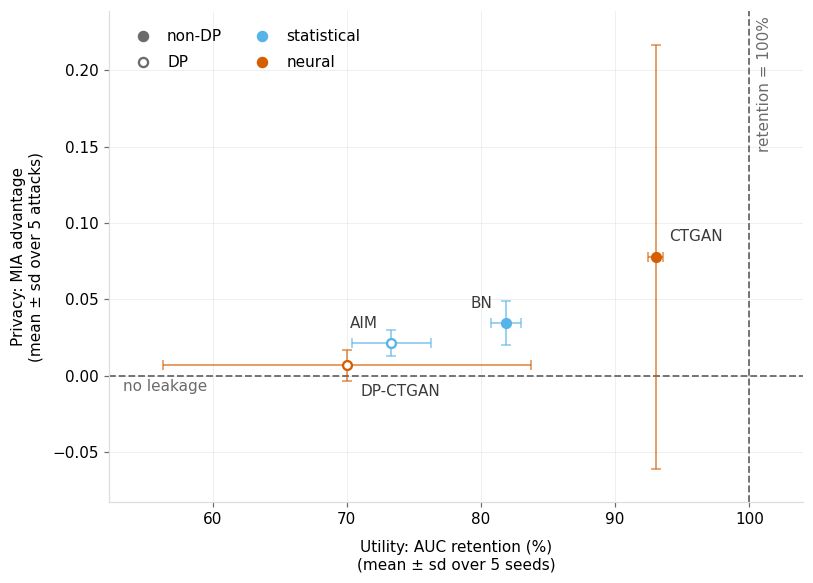

In [11]:
GENS_SCATTER = [g for g in GENS if g != "privbayes"]  # same drop as the bar chart
BLACK = "#000000"

# The scatter encodes FAMILY by hue and DP status by fill -- a different mapping from
# the bar chart, which needs one hue per generator to tell four bars apart inside an
# attack group. GEN_COLOR is left alone so the bar chart keeps that; the two figures
# answer different questions and the scatter has only four points to separate.
FAM_COLOR = {"statistical": "#56B4E9",   # Okabe-Ito Sky Blue
             "neural":      "#D55E00"}   # Okabe-Ito Vermillion
# Reference lines, their labels and the DP fill key are all scaffolding rather than
# data, so they share one neutral: MUTED, matching the chance line in the bar chart, at
# that cell's dashed style and weight.
REF, REF_LS, REF_LW = MUTED, "--", 1.2

util = pd.read_csv(UTILITY_RESULTS)
# reindex(GENS_SCATTER), not the raw groupby: METRICS still holds DPGAN's (and
# PrivBayes's) rows, and DPGAN's mean advantage of 0.137 is nearly twice CTGAN's. Left
# in, it would set yhi2 and squeeze the plotted points into the bottom half of a panel
# whose top half is empty.
adv_all = pd.concat([METRICS[f"{a}_{b}"].groupby("method").mia_advantage.mean()
                     .reindex(GENS_SCATTER).rename(f"{a}/{b}") for a, b in AVAIL], axis=1)
# ddof=1 -- the attacks are a sample of the attack battery, not the population of all
# possible attacks. (pandas already defaults to ddof=1; stated explicitly because
# numpy's std defaults to ddof=0 and the two are easy to confuse at this call site.)
sd_all = pd.concat([METRICS[f"{a}_{b}"].groupby("method").mia_advantage.std(ddof=1)
                    .reindex(GENS_SCATTER).rename(f"{a}/{b}") for a, b in AVAIL], axis=1)
# Limits come from mean +- sd, not the means alone: CTGAN's sd is 0.139 against a mean
# of 0.078, so a range fitted to the means would clip its whisker at both ends.
_ylo, _yhi = (adv_all - sd_all).min().min(), (adv_all + sd_all).max().max()
_ypad = .08 * (_yhi - _ylo)
ylo2, yhi2 = _ylo - _ypad, _yhi + _ypad
X = {}
for gen in GENS_SCATTER:
    u = util[util.method == gen]
    if len(u):
        X[gen] = (100 * float(u.retention_xgboost_mean.iloc[0]),
                  100 * float(u.retention_xgboost_std.iloc[0]))
xlo = min(m - s for m, s in X.values()) - 4
xhi = max(m + s for m, s in X.values()) + 4
xhi = max(xhi, 104)
XLIM = (xlo, xhi)

ncol = 2 if len(AVAIL) > 1 else 1
nrow = int(np.ceil(len(AVAIL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7.5 * ncol, 5.4 * nrow), squeeze=False,
                         sharex=True, sharey=True)
for k, (ntr, nte) in enumerate(AVAIL):
    ax = axes[k // ncol][k % ncol]
    _mia = METRICS[f"{ntr}_{nte}"].groupby("method").mia_advantage
    adv, adv_sd = _mia.mean(), _mia.std(ddof=1)
    ax.axhline(0, color=REF, ls=REF_LS, lw=REF_LW)
    ax.axvline(100, color=REF, ls=REF_LS, lw=REF_LW)
    ax.text(XLIM[0] + .02 * (XLIM[1] - XLIM[0]), -.002, "no leakage",
            fontsize=10, color=REF, va="top", ha="left")
    ax.text(100.6, yhi2 - .01 * (yhi2 - ylo2), "retention = 100%",
            fontsize=10, color=REF, va="top", ha="left", rotation=90)
    for gen in GENS_SCATTER:
        if gen not in X:
            continue
        xm, xs = X[gen]
        dp = GEN_DP[gen]
        col = FAM_COLOR[METHOD_CONFIG[gen]["kind"]]
        # Circles throughout: hue carries the family, fill carries DP status.
        face = "white" if dp else col
        # x whisker: sd of AUC retention over the 5 generation seeds.
        # y whisker: sd of MIA advantage over the 5 attacks in the battery -- a measure
        # of how unevenly the leakage signal is spread across attacks, not sampling
        # error. CTGAN's spans nearly the whole panel because Groundhog finds a large
        # advantage there while LocalNeighbourhood finds essentially none.
        ax.errorbar(xm, adv[gen], xerr=xs, yerr=adv_sd[gen], fmt="none", ecolor=col,
                    elinewidth=1.1, capsize=3, alpha=.7)
        # s=34 rather than 60: at s=60 the marker is ~7.8pt across and CTGAN's xerr is
        # only +-0.57 retention points (~5pt here), so the caps sat under the marker.
        ax.scatter(xm, adv[gen], s=34, marker="o",
                   facecolor=face, edgecolor=col, lw=1.5, zorder=3)
        dx, dy = {"privbayes": (9, -20), "ctgan": (9, 10),
                  "bayesian_network": (-9, 10), "aim": (-9, 10),
                  "dpgan": (9, -20), "dpctgan": (9, -20)}.get(gen, (9, 9))
        ax.annotate(SHORT[gen], (xm, adv[gen]), textcoords="offset points",
                    xytext=(dx, dy), fontsize=10, color=INK,
                    ha="left" if dx > 0 else "right")

    ax.set_xlim(*XLIM)
    ax.set_ylim(ylo2, yhi2); tidy(ax)
    ax.tick_params(labelcolor=BLACK)
    ax.grid(axis="both", color=GRID, lw=.6, alpha=.5)
    ax.tick_params(labelbottom=True, labelsize=10, labelcolor=BLACK)
    # The two whiskers are NOT the same kind of quantity and the labels have to say so:
    # x varies the generation seed with the attack battery fixed, y varies the attack
    # with the generator fixed. Naming both "mean +- sd" without the qualifier invites
    # reading them as one uncertainty.
    ax.set_xlabel("Utility: AUC retention (%)\n(mean ± sd over 5 seeds)",
                  fontsize=10, labelpad=8, color=BLACK)
    if k % ncol == 0:
        ax.set_ylabel("Privacy: MIA advantage\n(mean ± sd over 5 attacks)",
                      fontsize=10, labelpad=6, color=BLACK)
for k in range(len(AVAIL), nrow * ncol):
    axes[k // ncol][k % ncol].axis("off")

# The legend explains the ENCODING, not the generators: every point is already
# labelled by name on the plot, and a per-generator legend would carry two identical
# swatches (AIM is the only hollow sky-blue now that PrivBayes is dropped, but the
# scheme legend is still clearer than a per-generator one at four points). Two entries
# for fill, two for hue -- black on the fill entries so they do not imply a family, and
# filled markers on the hue entries so they do not imply a DP status.
_dot = lambda fc, ec: Line2D([], [], marker="o", linestyle="", markerfacecolor=fc,
                             markeredgecolor=ec, markeredgewidth=1.5, markersize=6)
# Upper LEFT, inside the panel: every point sits near y = 0 while the panel's top is
# set by CTGAN's tall whisker, so that corner is empty. ncol=2 fills column-major, which
# puts the two fill entries in one column and the two hue entries in the other -- the
# legend's own layout then mirrors the two things it encodes. borderaxespad keeps it
# inside the axes, clear of the y-axis spine and its ticks.
axes[0][0].legend(handles=[_dot(REF, REF), _dot("white", REF),
                           _dot(FAM_COLOR["statistical"], FAM_COLOR["statistical"]),
                           _dot(FAM_COLOR["neural"], FAM_COLOR["neural"])],
                  labels=["non-DP", "DP", "statistical", "neural"],
                  loc="upper left", ncol=2, frameon=False, fontsize=10,
                  handletextpad=.6, columnspacing=1.6, labelspacing=.7,
                  borderaxespad=.8)

fig.tight_layout()
fig.savefig(FIG_PAPER / "privacy_utility_tradeoff.png", bbox_inches="tight")
plt.show()

dpctgan: eps=0.1 -> ret 57.7+-15.8%, adv -0.0072+-0.0294, eps=1 -> ret 70.0+-13.7%, adv +0.0069+-0.0102, eps=10 -> ret 73.1+-8.8%, adv +0.0029+-0.0293, eps=100 -> ret 68.5+-9.2%, adv +0.0181+-0.0184
aim eps track: nothing for eps=[10.0] -- generate with sdg/generate_smartnoise.py aim --epsilon <e>, score with evaluation/eval_utility.py --generator aim --epsilon <e>, and audit under results/eps_sweep/aim/
aim: eps=0.1 -> ret 78.4+-4.9%, adv -0.0120+-0.0152, eps=1 -> ret 73.3+-2.9%, adv +0.0214+-0.0086


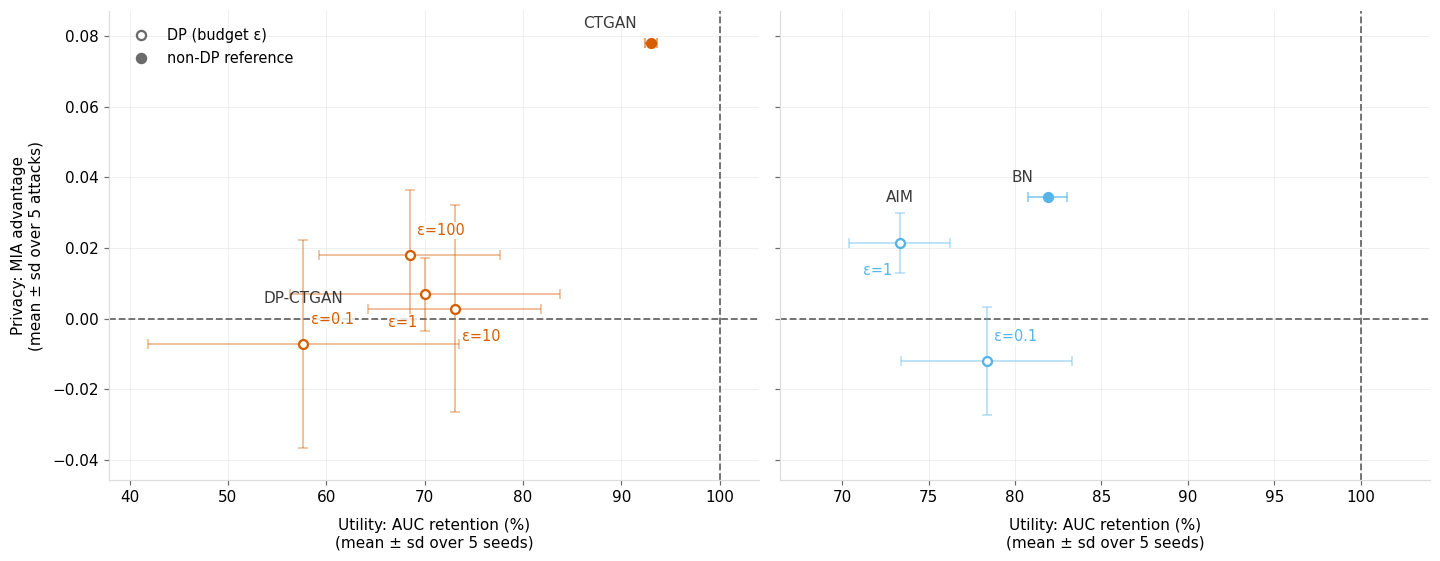

In [29]:
# ---- Supplementary: each DP generator across the formal budget, vs its non-DP twin ----
# The main tradeoff plot has one point per generator at eps = 1.0. This figure zooms on
# the two generators that have an eps sweep on BOTH axes, one panel per family, with the
# non-DP counterpart as the reference for "no noise at all":
#
#   neural       DP-CTGAN at eps 0.1 / 1 / 10 / 100      reference: CTGAN
#   statistical  AIM      at eps 0.1 / 1 / 10            reference: BayesNet
#                (AIM has no eps = 100 privacy audit)
#
#   privacy   results/eps_sweep/{dp_ctgan,aim}/eps{e}/1000_2500/effeps_{gen}_1000_2500.csv
#             (eps = 1.0 is the 1000/2500 stage of the sample-size sweep, i.e. METRICS
#             via cell 5, so that point coincides with the one in the main plot)
#   utility   evaluation/results/smartnoise/utility_summary_{gen}_eps{e}.csv, from
#             eval_utility.py --generator {gen} --epsilon {e}  (eps = 1.0 is the
#             {gen} row of utility_summary.csv)
#
# Whiskers keep the meaning they have in the main figure: x is the sd of AUC retention
# over the 5 generation seeds, y the sd of MIA advantage over the 5 attacks. The
# REFERENCE gets no y whisker: CTGAN's is +-0.14, which would set the y range and
# squash the eps track into a thin band near zero. Its mean still counts towards the
# range. The only in-plot text is the generator names and the eps labels (no titles,
# notes or connecting lines), so the reference's omitted sd and the eps = 10 / 100
# caveat below belong in the caption.
#
# Depends on cell 16 for FAM_COLOR, REF/REF_LS/REF_LW, BLACK, INK, GRID and tidy().
#
# eps is a STOPPING RULE in SmartNoise, not a noise calibration (cell 5's note), so for
# DP-CTGAN the eps = 10 and eps = 100 arms are the SAME mechanism: on the full 21,523-row
# training split all 300 epochs cost only eps ~= 3.98, so neither target binds and both
# stopped at the epoch cap. Their difference is noise, not an eps effect (say so in the
# caption). At eps = 0.1 the accountant already reads 0.159 before the first step,
# so 0 epochs train and the generator is an untrained network.
_focus_st = f"{AVAIL[-1][0]}_{AVAIL[-1][1]}"
_SWEEP = BENCH / "results" / "eps_sweep"
_SMARTNOISE = UTILITY_RESULTS.parent / "smartnoise"
FIG_SUPP = FIG_PAPER.parent / "supplementary"
util = pd.read_csv(UTILITY_RESULTS)

#        (DP generator, sweep dir, eps list,               non-DP reference,   family)
ZOOM = [("dpctgan", "dp_ctgan", [0.1, 1.0, 10.0, 100.0], "ctgan",            "neural"),
        ("aim",     "aim",      [0.1, 1.0, 10.0],        "bayesian_network", "statistical")]


def _point(gen, sweep_dir, eps):
    """(retention mean %, retention sd, adv mean, adv sd) at one budget, or None if absent."""
    if eps == 1.0:
        _m = METRICS[_focus_st]
        adv = _m.loc[_m.method == gen, "mia_advantage"]
        u = util[util.method == gen]
    else:
        f_priv = _SWEEP / sweep_dir / f"eps{eps:g}" / _focus_st / f"effeps_{gen}_{_focus_st}.csv"
        f_util = _SMARTNOISE / f"utility_summary_{gen}_eps{eps:g}.csv"
        if not (f_priv.exists() and f_util.exists()):
            return None
        adv = pd.read_csv(f_priv).mia_advantage
        u = pd.read_csv(f_util)
    if not len(adv) or not len(u):
        return None
    return (100 * float(u.retention_xgboost_mean.iloc[0]),
            100 * float(u.retention_xgboost_std.iloc[0]),
            float(adv.mean()), float(adv.std(ddof=1)))


panels = []
for gen, sweep_dir, eps_list, ref, fam in ZOOM:
    pts = {}
    for e in eps_list:
        p = _point(gen, sweep_dir, e)
        if p is not None:
            pts[e] = p
    miss = [e for e in eps_list if e not in pts]
    if miss:
        print(f"{gen} eps track: nothing for eps={miss} -- generate with "
              f"sdg/generate_smartnoise.py {gen} --epsilon <e>, score with "
              f"evaluation/eval_utility.py --generator {gen} --epsilon <e>, and audit "
              f"under results/eps_sweep/{sweep_dir}/")
    if pts:
        panels.append((gen, ref, fam, pts, _point(ref, None, 1.0)))
    print(f"{gen}: " + ", ".join(f"eps={e:g} -> ret {m:.1f}+-{s:.1f}%, adv {a:+.4f}+-{sd:.4f}"
                                 for e, (m, s, a, sd) in pts.items()))

if panels:
    # One y range for both panels so the two families are comparable. Track whiskers set
    # it; the reference contributes its MEAN only (see header).
    _ys = [a + d * s for _, _, _, pts, _ in panels for _, _, a, s in pts.values() for d in (-1, 1)]
    _ys += [r[2] for *_, r in panels if r is not None]
    _pad = .08 * (max(_ys) - min(_ys))
    ylo3, yhi3 = min(_ys) - _pad, max(_ys) + _pad

    # (dx, dy, ha) per eps, tuned so no label sits on another point's marker or on its
    # own vertical whisker: the top and far-left points label up-and-right, eps = 1 and
    # eps = 10 label below (eps = 1 to the left, eps = 10 to the right). The white bbox
    # keeps a label legible where it does cross somebody's whisker. Tuned from the
    # geometry only -- check it on the first render.
    _EPS_OFF = {0.1: (5, 13, "left"), 1.0: (-5, -21, "right"),
                10.0: (5, -21, "left"), 100.0: (5, 13, "left")}

    fig, axes = plt.subplots(1, len(panels), figsize=(6.6 * len(panels), 5.2),
                             squeeze=False, sharey=True)
    for ax, (gen, ref, fam, pts, rpt) in zip(axes[0], panels):
        col = FAM_COLOR[fam]
        ax.axhline(0, color=REF, ls=REF_LS, lw=REF_LW)
        ax.axvline(100, color=REF, ls=REF_LS, lw=REF_LW)
        for e, (xm, xs, ym, ys) in pts.items():
            ax.errorbar(xm, ym, xerr=xs, yerr=ys, fmt="none", ecolor=col,
                        elinewidth=1.1, capsize=3, alpha=.45)
            ax.scatter(xm, ym, s=34, marker="o", facecolor="white", edgecolor=col,
                       lw=1.5, zorder=3)
            dx, dy, ha = _EPS_OFF.get(e, (5, 13, "left"))
            ax.annotate(f"ε={e:g}", (xm, ym), textcoords="offset points",
                        xytext=(dx, dy), fontsize=9.5, color=col, ha=ha,
                        bbox=dict(fc="white", ec="none", pad=.6, alpha=.8))
        # The generator's name once, above the leftmost point, so the track is
        # identified without repeating it at every budget.
        _e_left = min(pts, key=lambda e: pts[e][0])
        ax.annotate(SHORT.get(gen, gen), (pts[_e_left][0], pts[_e_left][2]),
                    textcoords="offset points", xytext=(0, 27), fontsize=10,
                    color=INK, ha="center")
        xs_ = [(m, s) for m, s, _, _ in pts.values()]
        if rpt is not None:
            rm, rs, ra, rsd = rpt
            # Filled = non-DP, same encoding as the main figure. x whisker only.
            ax.errorbar(rm, ra, xerr=rs, fmt="none", ecolor=col, elinewidth=1.1,
                        capsize=3, alpha=.7)
            ax.scatter(rm, ra, s=34, marker="o", facecolor=col, edgecolor=col,
                       lw=1.5, zorder=3)
            ax.annotate(SHORT.get(ref, ref), (rm, ra), textcoords="offset points",
                        xytext=(-9, 10), fontsize=10, color=INK, ha="right")
            xs_.append((rm, rs))
        ax.set_xlim(min(m - s for m, s in xs_) - 4, max(104, max(m + s for m, s in xs_) + 4))
        ax.set_ylim(ylo3, yhi3); tidy(ax)
        ax.grid(axis="both", color=GRID, lw=.6, alpha=.5)
        ax.tick_params(labelbottom=True, labelsize=10, labelcolor=BLACK)
        ax.set_xlabel("Utility: AUC retention (%)\n(mean ± sd over 5 seeds)",
                      fontsize=10, labelpad=8, color=BLACK)
    axes[0][0].set_ylabel("Privacy: MIA advantage\n(mean ± sd over 5 attacks)",
                          fontsize=10, labelpad=6, color=BLACK)
    _dot = lambda fc, ec: Line2D([], [], marker="o", linestyle="", markerfacecolor=fc,
                                 markeredgecolor=ec, markeredgewidth=1.5, markersize=6)
    axes[0][0].legend(handles=[_dot("white", REF), _dot(REF, REF)],
                      labels=["DP (budget ε)", "non-DP reference"],
                      loc="upper left", frameon=False, fontsize=9.5, borderaxespad=.8)
    fig.tight_layout()
    fig.savefig(FIG_SUPP / "privacy_utility_eps_track.png", bbox_inches="tight")
    plt.show()


## 6. Formal epsilon sweep — DPGAN

**DRAFT — results land after the overnight run.** Every cell below no-ops with a
message until `results/eps_sweep/eps_sweep_summary.csv` exists.

Sections 1–5 vary the audit size at a fixed formal budget of ε = 1.0. This section holds
the audit size at 1000/2500 and varies ε instead, for DPGAN only, following
Chida et al. (MDAI 2024) — who swept PrivBayes at ε ∈ {0.1, 1, 10, 100} and audited with
TAPAS at exactly these counts. Applying that design to a DP-SGD **neural** generator is
the new part.

| | |
|---|---|
| ε swept | 0.1, 1.0, 10, 100 (ε = 1.0 reused from §1–5, not re-run) |
| audit | 1000/2500, 5-attack MIA battery, same background / target / attacks |
| utility | 5 seeds on the full 21,523-row split, TSTR/TRTR + 4 fidelity metrics |
| source | `audits/run_dpgan_eps_sweep.py`, `eps_sweep_pipeline/eps_sweep_{generate,evaluate,aggregate}.py` |

**Three caveats to carry into any reading of these panels.**

1. **σ is not a function of ε alone.** Opacus solves for the noise multiplier from
   (ε, δ, sample_rate, epochs), and synthcity derives δ and the sample rate from
   whatever frame it is handed. The audited 500-row world and the 21,523-row utility
   world therefore run at *different* σ **and different δ** at the same nominal ε —
   σ ≈ 11.7 vs ≈ 2.7 at ε = 1.0. The privacy panel and the utility panel are not
   measuring the same mechanism, and no amount of extra audit samples fixes that.
2. **δ moves with n and is not pinned** (`gan.py:590–591`, `dp_delta = 1/len(X)`).
   Left alone deliberately — pinning it would make this sweep a different mechanism
   from every other DPGAN number in the repo.
3. **`poisson_sampling=False`** (`gan.py:607`) while the accountant that produced σ
   assumes Poisson subsampling. The formal guarantee is an approximation throughout,
   so ε_eff exceeding ε would not by itself prove an implementation fault.

ε is reported as passed to synthcity. Opacus accounts under add/remove while this
threat model *swaps* one record for another, so the comparable replacement-relation
budget is 2ε — plotted as a second reference line, not folded into the axis.


In [12]:
# ---- load the sweep (no-op until the overnight run lands) ----
EPS_DIR = BENCH / "results" / "eps_sweep" / "dpgan"
SPIKE_DIR = BENCH / "results" / "extras" / "dpgan_spike_diagnosis"
EPS_SUMMARY = EPS_DIR / "eps_sweep_summary.csv"
EPS_PER_ATTACK = EPS_DIR / "eps_sweep_privacy_per_attack.csv"

EPS = pd.read_csv(EPS_SUMMARY) if EPS_SUMMARY.exists() else None
EPS_ATK = pd.read_csv(EPS_PER_ATTACK) if EPS_PER_ATTACK.exists() else None

if EPS is None:
    print(f"not found: {EPS_SUMMARY.relative_to(BENCH)}\n"
          "Run, in order:\n"
          "  python benchmark_tapas/eps_sweep_pipeline/eps_sweep_sigma_check.py\n"
          "  python benchmark_tapas/eps_sweep_pipeline/eps_sweep_generate.py\n"
          "  python benchmark_tapas/eps_sweep_pipeline/eps_sweep_evaluate.py\n"
          "  python benchmark_tapas/audits/run_dpgan_eps_sweep.py        # ~13 h\n"
          "  python benchmark_tapas/eps_sweep_pipeline/eps_sweep_aggregate.py")
else:
    EPS = EPS.sort_values("formal_epsilon").reset_index(drop=True)
    done = EPS.worst_case_eff_eps_low.notna().sum() if "worst_case_eff_eps_low" in EPS else 0
    print(f"{len(EPS)} eps arms | {done} with privacy | "
          f"eps = {', '.join(f'{e:g}' for e in EPS.formal_epsilon)}")
    cols = [c for c in ["formal_epsilon", "sigma_audit", "sigma_utility",
                        "tstr_auc_xgb_mean", "KSComplement_mean",
                        "worst_case_eff_eps_low", "worst_case_eff_eps_high",
                        "worst_case_attack", "degenerate_pool"] if c in EPS.columns]
    display(EPS[cols].style.format(precision=3).hide(axis="index"))


4 eps arms | 4 with privacy | eps = 0.1, 1, 10, 100


formal_epsilon,sigma_audit,sigma_utility,tstr_auc_xgb_mean,KSComplement_mean,worst_case_eff_eps_low,worst_case_eff_eps_high,worst_case_attack,degenerate_pool
0.100,80.000,22.500,0.528,0.224,0.000,0.423,Groundhog,False
1.000,11.719,2.656,0.509,0.289,1.761,2.780,Groundhog,False
10.000,2.014,0.688,0.435,0.321,0.000,0.009,Groundhog,False
100.000,0.527,0.352,0.531,0.280,0.000,0.010,Groundhog,False


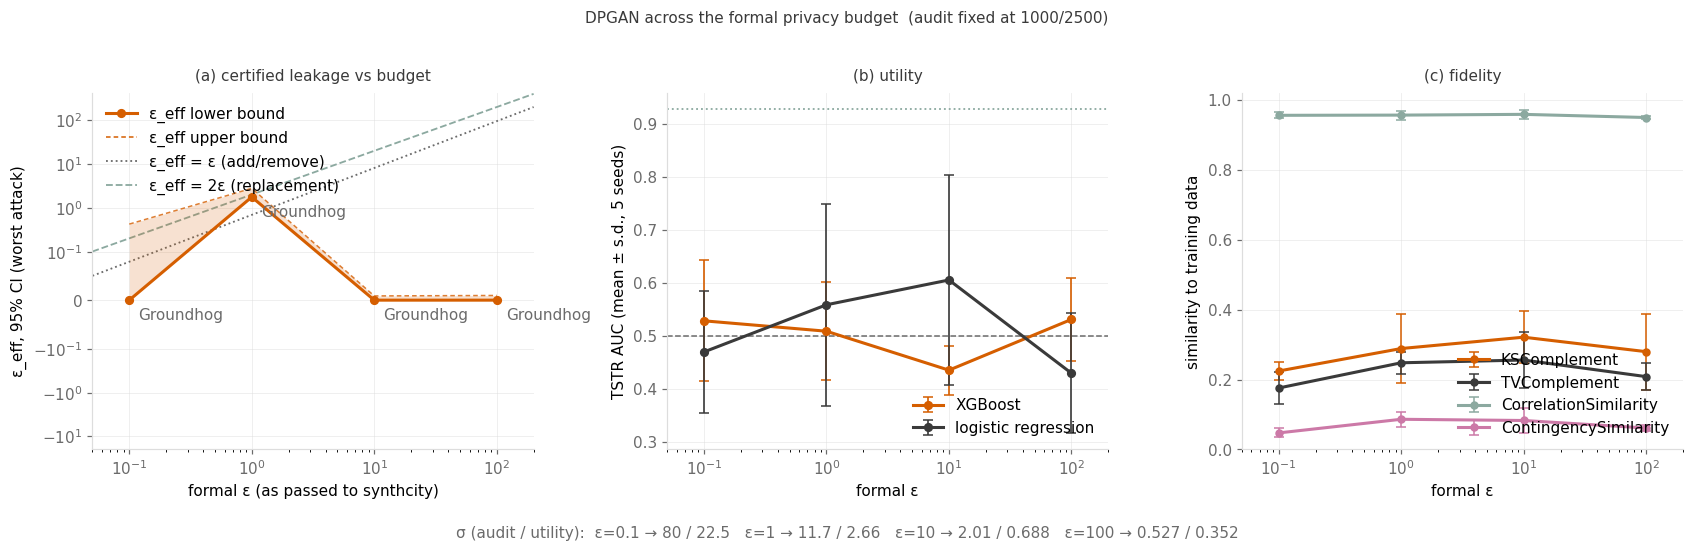

In [13]:
# ---- three panels against formal epsilon (log x throughout) ----
if EPS is None:
    print("skipped: run the sweep first (see the cell above)")
else:
    have = EPS.dropna(subset=["worst_case_eff_eps_low"]) if "worst_case_eff_eps_low" in EPS else EPS.iloc[:0]
    x = EPS.formal_epsilon.values
    lo, hi = x.min() / 2, x.max() * 2

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))

    # (a) certified leakage vs the budget that was paid for.
    ax = axes[0]
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls=":", lw=1.2, zorder=1)
    ax.plot([lo, hi], [2 * lo, 2 * hi], color=SAGE, ls="--", lw=1.2, zorder=1)
    if len(have):
        xs = have.formal_epsilon.values
        elo, ehi = have.worst_case_eff_eps_low.values, have.worst_case_eff_eps_high.values
        ax.fill_between(xs, elo, ehi, color=ORANGE, alpha=.18, lw=0)
        ax.plot(xs, elo, color=ORANGE, lw=2, marker="o", ms=5, zorder=3)
        ax.plot(xs, ehi, color=ORANGE, lw=1, ls=(0, (3, 2)), alpha=.8, zorder=3)
        for _, r in have.iterrows():
            ax.annotate(str(r.worst_case_attack), (r.formal_epsilon, r.worst_case_eff_eps_low),
                        textcoords="offset points", xytext=(6, -13), fontsize=10, color=MUTED)
    ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=0.1)
    ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε (as passed to synthcity)", fontsize=10)
    ax.set_ylabel("ε_eff, 95% CI (worst attack)", fontsize=10)
    ax.set_title("(a) certified leakage vs budget", fontsize=10, color=INK, pad=8)
    ax.legend(handles=[
        Line2D([], [], color=ORANGE, lw=2, marker="o", ms=5, label="ε_eff lower bound"),
        Line2D([], [], color=ORANGE, lw=1, ls=(0, (3, 2)), label="ε_eff upper bound"),
        Line2D([], [], color=MUTED, ls=":", lw=1.2, label="ε_eff = ε (add/remove)"),
        Line2D([], [], color=SAGE, ls="--", lw=1.2, label="ε_eff = 2ε (replacement)")],
        frameon=False, fontsize=10, loc="upper left")

    # (b) utility. TRTR is the same real-data ceiling at every eps.
    ax = axes[1]
    if "tstr_auc_xgb_mean" in EPS and EPS.tstr_auc_xgb_mean.notna().any():
        u = EPS.dropna(subset=["tstr_auc_xgb_mean"])
        if "trtr_auc_xgb" in u and u.trtr_auc_xgb.notna().any():
            ax.axhline(float(u.trtr_auc_xgb.dropna().iloc[0]), color=SAGE, ls=":", lw=1.2)
        ax.axhline(0.5, color=MUTED, ls="--", lw=1)
        for col, lbl, c in (("tstr_auc_xgb", "XGBoost", ORANGE),
                            ("tstr_auc_lr", "logistic regression", CHARCOAL)):
            if f"{col}_mean" not in u: continue
            m, s = u[f"{col}_mean"].values, u[f"{col}_std"].values
            ax.errorbar(u.formal_epsilon, m, yerr=s, color=c, lw=2, marker="o", ms=5,
                        capsize=3, elinewidth=1.1, label=lbl)
        ax.legend(frameon=False, fontsize=10, loc="lower right")
    ax.set_xscale("log"); ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε", fontsize=10)
    ax.set_ylabel("TSTR AUC (mean ± s.d., 5 seeds)", fontsize=10)
    ax.set_title("(b) utility", fontsize=10, color=INK, pad=8)

    # (c) fidelity. All four are similarity scores in [0,1], higher = better.
    ax = axes[2]
    FID = [("KSComplement", ORANGE), ("TVComplement", CHARCOAL),
           ("CorrelationSimilarity", SAGE), ("ContingencySimilarity", ROSE)]
    for name, c in FID:
        if f"{name}_mean" not in EPS or EPS[f"{name}_mean"].isna().all(): continue
        f = EPS.dropna(subset=[f"{name}_mean"])
        ax.errorbar(f.formal_epsilon, f[f"{name}_mean"], yerr=f[f"{name}_std"],
                    color=c, lw=2, marker="o", ms=4.5, capsize=3, elinewidth=1,
                    label=name)
    ax.set_xscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(0, 1.02)
    ax.set_xlabel("formal ε", fontsize=10)
    ax.set_ylabel("similarity to training data", fontsize=10)
    ax.set_title("(c) fidelity", fontsize=10, color=INK, pad=8)
    ax.legend(frameon=False, fontsize=10, loc="lower right")

    for a in axes:
        tidy(a); a.grid(color=GRID, lw=.6, alpha=.5)
    # sigma is what eps actually buys; annotate rather than add a fourth panel.
    if "sigma_audit" in EPS:
        note = "σ (audit / utility):  " + "   ".join(
            f"ε={r.formal_epsilon:g} → {r.sigma_audit:.3g} / {r.sigma_utility:.3g}"
            for _, r in EPS.iterrows())
        fig.text(.5, -.045, note, ha="center", fontsize=10, color=MUTED)
    fig.suptitle("DPGAN across the formal privacy budget  (audit fixed at 1000/2500)",
                 fontsize=10, color=INK, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_SUPP / "eps_sweep_dpgan.png", bbox_inches="tight")
    plt.show()


In [14]:
# ---- per-attack detail: which attack sets the bound, and does that change with eps ----
if EPS_ATK is None:
    print("skipped: run the sweep first")
else:
    piv = (EPS_ATK.pivot_table(index="attack_short", columns="formal_epsilon",
                               values="eps_low_95")
           .reindex([a for a in ATTACK_ORDER if a in set(EPS_ATK.attack_short)]))
    print("ε_eff lower bound (95%) by attack x formal ε\n")
    print(piv.to_string(float_format=lambda v: f"{v:.3f}"))
    print("\nMIA advantage (TP - FP)\n")
    print(EPS_ATK.pivot_table(index="attack_short", columns="formal_epsilon",
                              values="mia_advantage")
          .reindex(piv.index).to_string(float_format=lambda v: f"{v:.3f}"))

    cols = [c for c in ["formal_epsilon", "attack_short", "auc", "tp", "fp", "tn", "fn",
                        "mia_advantage", "privacy_gain", "eps_low_95", "eps_high_95",
                        "eff_eps_tau", "eff_eps_tau_inverse"] if c in EPS_ATK.columns]
    display(EPS_ATK[cols].style.format(precision=3).hide(axis="index"))


ε_eff lower bound (95%) by attack x formal ε

formal_epsilon         0.1    1.0    10.0   100.0
attack_short                                     
Groundhog              0.000  1.761  0.000  0.000
ShadowModelling        0.000  0.241  0.000  0.000
LocalNeighbourhood     0.000  0.000  0.000  0.000
ProbabilityEstimation  0.000  0.000  0.000  0.000
ClosestDistance        0.000  0.000  0.000  0.000

MIA advantage (TP - FP)

formal_epsilon         0.1    1.0    10.0   100.0
attack_short                                     
Groundhog              0.066  0.452  0.041  0.133
ShadowModelling       -0.014  0.176  0.026  0.006
LocalNeighbourhood     0.000  0.000  0.000  0.000
ProbabilityEstimation  0.016  0.037  0.001  0.004
ClosestDistance        0.014  0.018  0.005  0.006


formal_epsilon,attack_short,auc,tp,fp,tn,fn,mia_advantage,privacy_gain,eps_low_95,eps_high_95,eff_eps_tau,eff_eps_tau_inverse
0.100,ClosestDistance,0.493,0.263,0.250,0.750,0.737,0.014,0.986,0.000,0.004,-2.139,0.000
0.100,Groundhog,0.549,0.514,0.449,0.551,0.486,0.066,0.934,0.000,0.423,0.570,0.000
0.100,LocalNeighbourhood,0.500,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.004,0.000,0.000
0.100,ProbabilityEstimation,0.519,0.298,0.282,0.718,0.702,0.016,0.984,0.000,0.009,-86.491,0.000
0.100,ShadowModelling,0.497,0.470,0.484,0.516,0.530,-0.014,1.014,0.000,0.004,0.180,0.000
1.000,ClosestDistance,0.504,0.457,0.438,0.562,0.543,0.018,0.982,0.000,0.006,nan,nan
1.000,Groundhog,0.811,0.720,0.268,0.732,0.280,0.452,0.548,1.761,2.780,nan,nan
1.000,LocalNeighbourhood,0.500,0.000,0.000,1.000,1.000,0.000,1.000,0.000,0.004,nan,nan
1.000,ProbabilityEstimation,0.517,0.578,0.542,0.458,0.422,0.037,0.963,0.000,0.013,nan,nan
1.000,ShadowModelling,0.619,0.588,0.412,0.588,0.412,0.176,0.824,0.241,0.572,nan,nan


### 6.1 Side by side with Chida et al.

The two cells below rebuild Chida et al.'s **Table 1** and **Fig. 4** on **SmartNoise
DP-CTGAN**, in their layout and their row/panel order (ε = 100 → 0.1), so the two papers'
results can be read against each other directly. They add no new computation — the same
per-attack CSVs and raw scores the spike diagnosis produced, presented their way. §7.2
rebuilds the identical pair for AIM using the same two functions.

**Why their format is worth adopting here.** The three-panel figure above answers "does ε
buy anything?" across privacy, utility and fidelity at once. Chida's format answers a
narrower question more sharply: *how far is the measured leakage from the budget that was
paid for, and does the confidence level change that answer?* Reporting all three
confidence levels (0.90 / 0.95 / 0.99) matters because ε_eff is a Clopper–Pearson
interval — a bound that widens as you demand more confidence — not a point estimate.

**The floor, and why matching digits are the point.** When an attack achieves nothing, the
interval collapses to a function of the sample count alone. With 2,500 test datasets that
floor is `[0, ~0.0039]` at 95% — and Chida's PrivBayes rows at ε = 100 and ε = 10 report
`0 / 0.003895`. DP-CTGAN's ε = 1.0 row lands on `0 / 0.003884`, the same floor. So a zero
row here is not "a small amount of leakage"; it is the smallest quantity this audit size
can express.

**The headline: the ε = 1.0 spike does not reproduce.** This table is what the spike
diagnosis was built to produce, and it answers the question. Every DP-CTGAN row sits at
the certified floor — `eps_low = 0` at all four budgets, with 95% upper bounds spanning
0.0039 to 0.0127 — whereas synthcity's DPGAN under the identical threat model, counts and
attack battery certified **ε_eff = 1.761 [1.761, 2.780]** at ε = 1.0 alone, its other three
budgets sitting at the same floor DP-CTGAN occupies throughout.

That is the discriminating result. An independent implementation of the same idea —
CTGAN architecture, DP-SGD on the discriminator — shows no anomaly at ε = 1.0. So the
spike belongs to *synthcity's implementation*, not to DP-SGD-on-CTGAN as a method, and the
claim the write-up can support narrows accordingly.

**Two things to carry when citing this table.**

1. **ε is a stopping rule here, so the index is not the budget that was paid.** SmartNoise
   fixes σ = 5 and breaks training when the accountant says the budget is spent — and it
   checks at the *top* of each epoch, so the released model has already overshot. On the
   500-row audit background `batch_size = 500 = |background|` gives sampling rate 1.0 and
   no amplification: ε = 1.0 buys **3 epochs** and actually spends **1.473**.

   That 1.473 is measured by `run_dpctgan_audit.py --probe`, *not* read from these arms.
   All four spike-diagnosis `meta.json` files carry `last_epsilon_spent: null` — the
   diagnostics are read off the threat model's pickled generator, which on a resumed
   process has fitted nothing in that invocation and so reports nothing. The probe fits
   the same configuration on the same 500-row background, so the number transfers, but
   these arms do not record it themselves. The epoch sweep in §6.4 does, because those
   runs completed their fits in-process (cap 300 → 31.62, 500 → 45.60, 750 → 61.67).

2. **The upper bounds are not monotone in ε** (0.0127, 0.0099, 0.0039, 0.0079 at 95% for
   100 / 10 / 1 / 0.1). Groundhog sets the bound at every budget. None of the variation is
   certified — every lower bound is zero — so this is movement inside the null, not a
   dose-response curve.


In [15]:
# ---- Chida et al. Table 1 equivalent: eff-epsilon at three confidence levels ----
# Written as functions because section 7.2 rebuilds the identical pair of figures for
# AIM. The DPGAN version this replaced read EPS_ATK, a sweep-specific aggregate; these
# read each arm's own effeps CSV, which is the same content and works for any generator
# that has an epsilon sweep.

def chida_arms(root, method, nested, stage="1000_2500", extra=None):
    """{formal_eps: results dir} for every arm of one generator's eps sweep.

    `nested` distinguishes the two layouts in this repo: the DPGAN sweep writes
    eps{e}/effeps_*.csv, the AIM and DP-CTGAN audits write eps{e}/{stage}/effeps_*.csv.
    `extra` carries an arm that sits outside eps_sweep/ -- eps=1.0, which lives in
    sample_size_sweep/{generator}/{stage}/.
    """
    arms = dict(extra or {})
    for d in sorted(Path(root).glob("eps*")):
        if not d.is_dir():
            continue
        cand = (d / stage) if nested else d
        if (cand / f"effeps_{method}_{stage}.csv").exists():
            arms[float(d.name[3:])] = cand
    return arms


def chida_table(arms, method, label, stage="1000_2500", out_csv=None):
    """Worst-case eff-epsilon per budget at 90/95/99% confidence, Chida's row order.

    Worst case over attacks = the largest certified LOWER bound, which is what
    EffectiveEpsilonReport reports for the mechanism as a whole.
    """
    if not arms:
        print(f"skipped: no {label} eps arms found")
        return None
    rows = []
    for eps in sorted(arms, reverse=True):          # Chida orders 100 -> 0.1
        d = pd.read_csv(arms[eps] / f"effeps_{method}_{stage}.csv")
        d["attack_short"] = d.attack.str.split("(").str[0]
        row = {"eps": eps}
        for c in (90, 95, 99):
            best = d.loc[d[f"eps_low_{c}"].idxmax()]
            row[f"{c / 100:.2f} (low)"] = best[f"eps_low_{c}"]
            row[f"{c / 100:.2f} (high)"] = best[f"eps_high_{c}"]
        row["attack"] = d.loc[d.eps_low_95.idxmax(), "attack_short"]
        rows.append(row)
    tab = pd.DataFrame(rows).set_index("eps")
    if out_csv is not None:
        out_csv.parent.mkdir(parents=True, exist_ok=True)
        tab.to_csv(out_csv)                          # full precision

    # Exact zeros print as "0", as in Chida's Table 1: a certified lower bound of zero
    # is an exact result, not a rounded small number, and "0.000000" reads as the latter.
    fmt = lambda v: "0" if v == 0 else f"{v:.6f}"
    print(f"Effective epsilon ({label}), worst case over the 5 attacks\n")
    print(tab.drop(columns="attack").to_string(float_format=fmt))
    print("\nattack setting the bound: " +
          ", ".join(f"eps={i:g} -> {r}" for i, r in tab["attack"].items()))

    # The Clopper-Pearson floor: with no leakage the interval depends only on the
    # sample count, so a zero row is not "a small number" -- it is the smallest number
    # 2500 test datasets can express. Chida's PrivBayes rows sit on the same floor.
    floor = tab[tab["0.95 (low)"] == 0]["0.95 (high)"]
    if len(floor):
        print(f"\nrows at the certified floor (eps_low = 0): "
              f"{', '.join(f'eps={i:g}' for i in floor.index)}")
        print(f"  their 95% upper bounds span {floor.min():.6f} to {floor.max():.6f}")
    return tab


# ---- DP-CTGAN: eps 0.1 / 10 / 100 from eps_sweep/dp_ctgan, eps 1.0 from sample_size_sweep ----
DPC_SWEEP = BENCH / "results" / "eps_sweep" / "dp_ctgan"
_dpc_eps1 = DPC_DIR / "1000_2500"
DPC_ARMS = chida_arms(DPC_SWEEP, "dpctgan", nested=True,
                      extra={1.0: _dpc_eps1} if (_dpc_eps1 / "effeps_dpctgan_1000_2500.csv").exists() else None)
CHIDA_TAB = chida_table(DPC_ARMS, "dpctgan", "DP-CTGAN, SmartNoise",
                        out_csv=DPC_SWEEP / "effeps_by_confidence_dpctgan.csv")
if DPC_ARMS:
    print("\nNOTE: epsilon is a STOPPING RULE for SmartNoise, not a noise calibration.")
    print("sigma is fixed at 5 and training breaks when the accountant says the budget")
    print("is spent -- and because the check runs at the TOP of each epoch, the released")
    print("model has already overshot. On the 500-row audit background the sampling rate")
    print("is 1.0 (batch_size 500 = |background|), so there is no amplification: eps=1.0")
    print("buys 3 epochs and actually spends 1.473. Read each row against the SPENT")
    print("value in that arm's meta.json, not against the nominal eps in the index.")


Effective epsilon (DP-CTGAN, SmartNoise), worst case over the 5 attacks

       0.90 (low)  0.90 (high)  0.95 (low)  0.95 (high)  0.99 (low)  0.99 (high)
eps                                                                             
100.0           0     0.016108           0     0.017944           0     0.021683
10.0            0     0.008904           0     0.009895           0     0.012007
1.0             0     0.003256           0     0.003884           0     0.005324
0.1             0     0.006833           0     0.007885           0     0.010089

attack setting the bound: eps=100 -> Groundhog, eps=10 -> Groundhog, eps=1 -> Groundhog, eps=0.1 -> Groundhog

rows at the certified floor (eps_low = 0): eps=100, eps=10, eps=1, eps=0.1
  their 95% upper bounds span 0.003884 to 0.017944

NOTE: epsilon is a STOPPING RULE for SmartNoise, not a noise calibration.
sigma is fixed at 5 and training breaks when the accountant says the budget
is spent -- and because the check runs at the TOP of

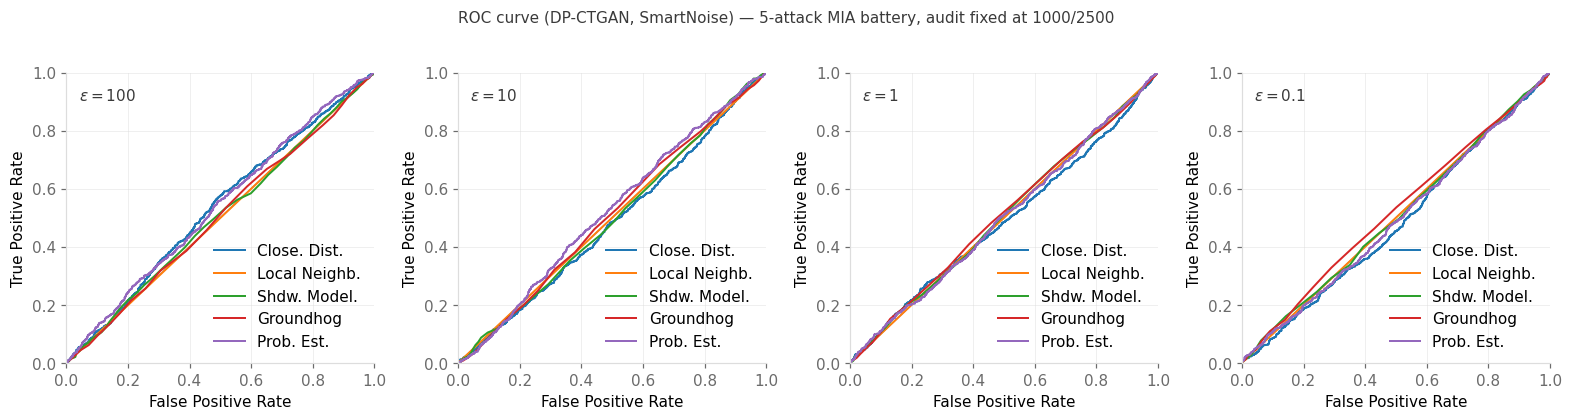

In [16]:
# ---- Chida et al. Fig 4 equivalent: one ROC panel per eps, all five attacks ----
from sklearn.metrics import roc_curve

# Chida's panel order (100 -> 0.1) and legend order, so the two figures read side by side.
CHIDA_EPS = [100.0, 10.0, 1.0, 0.1]
CHIDA_ATK = ["ClosestDistance", "LocalNeighbourhood", "ShadowModelling",
             "Groundhog", "ProbabilityEstimation"]
CHIDA_LBL = {"ClosestDistance": "Close. Dist.", "LocalNeighbourhood": "Local Neighb.",
             "ShadowModelling": "Shdw. Model.", "Groundhog": "Groundhog",
             "ProbabilityEstimation": "Prob. Est."}
# DELIBERATE DEPARTURE FROM THE REPO PALETTE. Chida et al. Fig. 4 was drawn with
# matplotlib's default tab10 cycle taken in this legend order, so reproducing those
# exact hues lets the two figures be laid side by side and read as one comparison.
# Every other figure in this notebook keeps the repo palette (ORANGE/CHARCOAL/SAGE/ROSE).
CHIDA_COL = {"ClosestDistance":       "#1f77b4",   # C0 blue
             "LocalNeighbourhood":    "#ff7f0e",   # C1 orange
             "ShadowModelling":       "#2ca02c",   # C2 green
             "Groundhog":             "#d62728",   # C3 red
             "ProbabilityEstimation": "#9467bd"}   # C4 purple


def chida_roc(arms, method, label, out_png, stage="1000_2500"):
    """One ROC panel per budget, five attacks each, in Chida's Fig. 4 layout.

    Panels follow CHIDA_EPS where present and then any remaining budgets, so an
    incomplete sweep still draws the arms it has rather than nothing.
    """
    order = [e for e in CHIDA_EPS if e in arms] + \
            [e for e in sorted(arms, reverse=True) if e not in CHIDA_EPS]
    panels = []
    for eps in order:
        f = arms[eps] / f"raw_scores_{method}_{stage}.csv"
        if not f.exists():
            continue
        d = pd.read_csv(f)
        d["attack_short"] = d.attack.str.split("(").str[0]
        if len(d):
            panels.append((eps, d))
    if not panels:
        print(f"skipped: no raw-score CSVs found for {label}")
        return

    fig, axes = plt.subplots(1, len(panels), figsize=(3.6 * len(panels), 3.7),
                             squeeze=False)
    for ax, (eps, d) in zip(axes[0], panels):
        ax.plot([0, 1], [0, 1], color=MUTED, lw=.8, zorder=1)          # chance
        for atk in CHIDA_ATK:
            s = d[d.attack_short == atk]
            if s.empty:
                continue
            fpr, tpr, _ = roc_curve(s.ground_truth, s.raw_score)
            ax.plot(fpr, tpr, color=CHIDA_COL[atk], lw=1.3,
                    label=CHIDA_LBL[atk], zorder=2)
        ax.text(.04, .95, rf"$\varepsilon = {eps:g}$", fontsize=10, color=INK,
                transform=ax.transAxes, va="top")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xticks(np.arange(0, 1.01, .2)); ax.set_yticks(np.arange(0, 1.01, .2))
        ax.set_xlabel("False Positive Rate", fontsize=10)
        ax.set_ylabel("True Positive Rate", fontsize=10)
        tidy(ax); ax.grid(color=GRID, lw=.5, alpha=.6)
        ax.legend(frameon=False, fontsize=10, loc="lower right")
    fig.suptitle(f"ROC curve ({label}) — 5-attack MIA battery, audit fixed at {stage.replace('_', '/')}",
                 fontsize=10, color=INK, y=1.02)
    fig.tight_layout()
    fig.savefig(out_png, bbox_inches="tight")
    plt.show()


chida_roc(DPC_ARMS, "dpctgan", "DP-CTGAN, SmartNoise",
          FIG_SUPP / "eps_sweep_roc_dpctgan.png")


### 6.2 The ε = 1.0 peak is real — and it is a peak, not a spike

The sweep above shows leakage at ε = 1.0 and nothing at 0.1, 10 or 100. DP cannot produce
that shape: more budget should mean more leakage, monotonically. Two explanations fit those
four points equally well and need different responses — either leakage genuinely peaks near
ε ≈ 1, or something specific to that one run made it leak and ε is incidental.

A single elevated point cannot separate them, so `diagnostics/eps_sweep_signal_scan.py` added
neighbours at ε = 0.3 and ε = 3.0. It measures the membership signal **directly in the
generated pools** — a classifier on per-dataset summary features, cross-validated within the
training pool — rather than going through the attack battery and the Clopper–Pearson bound,
which clips at zero and so cannot distinguish "no leakage" from "a little".

| ε | signal | permuted baseline | gap |
|---|---|---|---|
| 0.3 | 0.757 | 0.554 | **+0.203** |
| 1.0 | 0.874 | 0.501 | **+0.373** |
| 3.0 | 0.615 | 0.424 | **+0.191** |

Both neighbours sit clearly above their own baselines, with ε = 1.0 highest. Stitched
together with the audit-pool measurements the curve is unimodal — rising from 0.1 to 1,
falling from 1 to 100. **A real interior maximum, not a spike.** And the fresh ε = 1.0 pool
scored 0.874 against the archived pool's 0.892, six days and a separate cache apart, so the
ε = 1.0 row in the sweep above is a reproducible measurement rather than an artefact of the
run that produced it.

**The mechanism this implies.** DPGAN's empirical privacy is worst at *moderate* noise. Too
much and the output is garbage that buries any signal; too little and the GAN trains
properly and produces a smoothed distribution. In between, the discriminator is damaged
enough that the generator's output is driven by CTGAN's data transformer and conditional
sampler — **neither of which is privatised**, both fit directly on the input rows including
the target — while the output is still clean enough for that imprint to be readable. So
"more budget ⇒ more leakage" fails empirically for this implementation, which is exactly the
class of theory-versus-practice gap Chida et al. set out to detect.

**Two caveats to carry into any write-up.**

1. The permuted baselines wander between 0.424 and 0.554 rather than sitting at 0.5, so the
   null has real variance at n = 400 from a single permutation. The gaps (0.19–0.37) are
   much larger than that wobble, so the conclusion holds — but for publication the baseline
   should be averaged over several permutations per point, not one.
2. The six points are not strictly like-for-like. ε = 0.1, 10 and 100 were measured on the
   **1000-dataset audit pools**; ε = 0.3, 1 and 3 on **400-dataset scan pools**. The
   fresh-vs-archived agreement at ε = 1.0 (0.874 vs 0.892) suggests the sample size does not
   matter much here, but the figure below marks which points came from which.

 formal_epsilon  n_datasets  signal_auc  signal_auc_cv_std  permuted_auc
          0.300         400       0.757              0.048         0.554
          1.000         400       0.874              0.014         0.501
          3.000         400       0.615              0.032         0.424


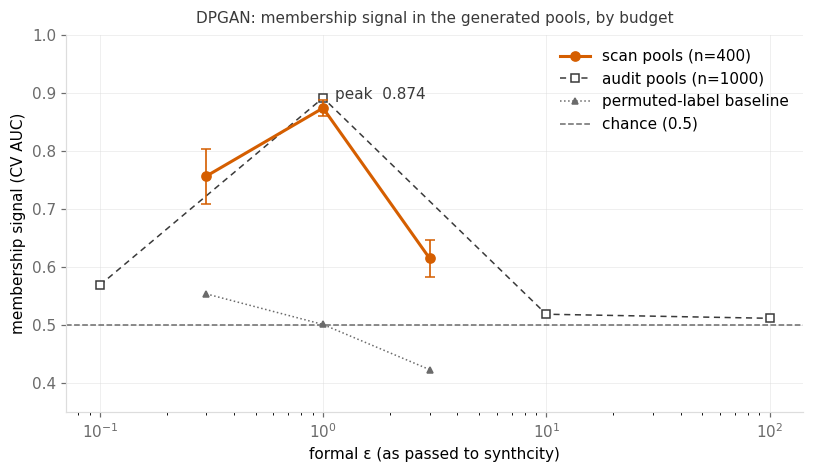

In [17]:
# ---- the membership-signal curve: is eps=1.0 a peak or a spike? ----
SCAN_CSV = SPIKE_DIR / "signal_scan.csv"

# The three budgets measured on the 1000-dataset AUDIT pools rather than by the scan.
# Carried as constants because they were computed from cache/dpgan*/datasets/ exports,
# which are gitignored -- so they cannot be re-derived from anything in results/.
# Provenance: same feature set and same classifier as the scan, n=1000 instead of n=400.
AUDIT_POOL_SIGNAL = {0.1: 0.569, 1.0: 0.892, 10.0: 0.519, 100.0: 0.512}

if not SCAN_CSV.exists():
    print(f"not found: {SCAN_CSV.relative_to(BENCH)}\n"
          "  run: python benchmark_tapas/diagnostics/eps_sweep_signal_scan.py")
else:
    scan = pd.read_csv(SCAN_CSV).sort_values("formal_epsilon")
    print(scan[["formal_epsilon", "n_datasets", "signal_auc", "signal_auc_cv_std",
                "permuted_auc"]].to_string(index=False,
                                           float_format=lambda v: f"{v:.3f}"))

    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    ax.axhline(0.5, color=MUTED, ls="--", lw=1)

    # audit-pool points first, so the scan curve draws over them
    ax_x = sorted(AUDIT_POOL_SIGNAL)
    ax.plot(ax_x, [AUDIT_POOL_SIGNAL[e] for e in ax_x], color=CHARCOAL, lw=1,
            ls=(0, (4, 3)), marker="s", ms=5, mfc="white", mec=CHARCOAL, zorder=2)

    ax.errorbar(scan.formal_epsilon, scan.signal_auc, yerr=scan.signal_auc_cv_std,
                color=ORANGE, lw=2, marker="o", ms=6, capsize=3, elinewidth=1.1, zorder=3)
    ax.plot(scan.formal_epsilon, scan.permuted_auc, color=MUTED, lw=1, ls=":",
            marker="^", ms=4, zorder=2)

    peak = scan.loc[scan.signal_auc.idxmax()]
    ax.annotate(f"peak  {peak.signal_auc:.3f}", (peak.formal_epsilon, peak.signal_auc),
                textcoords="offset points", xytext=(8, 6), fontsize=10, color=INK)

    ax.set_xscale("log")
    ax.set_ylim(0.35, 1.0)
    ax.set_xlabel("formal ε (as passed to synthcity)", fontsize=10)
    ax.set_ylabel("membership signal (CV AUC)", fontsize=10)
    ax.set_title("DPGAN: membership signal in the generated pools, by budget",
                 fontsize=10, color=INK, pad=8)
    ax.legend(handles=[
        Line2D([], [], color=ORANGE, lw=2, marker="o", ms=6, label="scan pools (n=400)"),
        Line2D([], [], color=CHARCOAL, lw=1, ls=(0, (4, 3)), marker="s", ms=5,
               mfc="white", label="audit pools (n=1000)"),
        Line2D([], [], color=MUTED, lw=1, ls=":", marker="^", ms=4,
               label="permuted-label baseline"),
        Line2D([], [], color=MUTED, ls="--", lw=1, label="chance (0.5)")],
        frameon=False, fontsize=10, loc="upper right")
    tidy(ax); ax.grid(color=GRID, lw=.6, alpha=.5)
    fig.tight_layout()
    fig.savefig(FIG_SUPP / "eps_sweep_signal_curve.png", bbox_inches="tight")
    plt.show()

### 6.3 Where does the spike come from? Isolating the cause

§6.2 established that the ε ≈ 1 peak is real and reproducible. This section asks *which
component produces it*. The measurement is a chain of four links, and the spike could
live in any of them:

```
synthcity DPGAN  →  generated data  →  TAPAS attacks  →  effective epsilon
      [3]                                    [0]              [1]
                        ↑ [2] is eps itself special near 1.0?
```

Four experiments, each swapping out one link:

| | what was swapped | result |
|---|---|---|
| **[0]** | the attacks — an independent classifier on the same pools | signal found anyway → **not the attacks** |
| **[1]** | the bound — Clopper–Pearson recomputed from raw scores | TAPAS is *conservative* → **not the arithmetic** |
| **[2]** | ε itself — 0.999 and 1.001, everything else identical | both still spike → **not the number 1.0** |
| **[3]** | the generator — SmartNoise DP-CTGAN, same TAPAS setup | flat at the floor → **not DP-SGD-on-CTGAN as a method** |

[0] is the curve in §6.2. The three panels below are [1], [2] and [3].

**Conclusion: the spike is specific to synthcity's DPGAN.** Every other link has been
ruled out, and an independent implementation of the same algorithm — trained to
completion at ε = 100, so not merely under-trained — shows no leakage at any budget.

**The caveat to carry.** "synthcity's implementation" is not yet narrowed to a single
cause, because the two libraries differ in more than their code: SmartNoise uses
`batch_size = 500` on a 500-row background (sampling rate 1.0, so no privacy
amplification), fixes σ = 5 rather than solving for it, and derives a different δ. The
sharpest remaining hypothesis is that synthcity's CTGAN preprocessing — VGM
mode-specific normalisation plus a conditional sampler, both fit on the **raw data with
no DP** — imprints the input distribution on the output, and that imprint dominates once
DP-SGD noise has destroyed the discriminator. Testing that would mean a matched arm
(DP-CTGAN at `batch_size = 200`) and inspecting what synthcity's transformer retains.

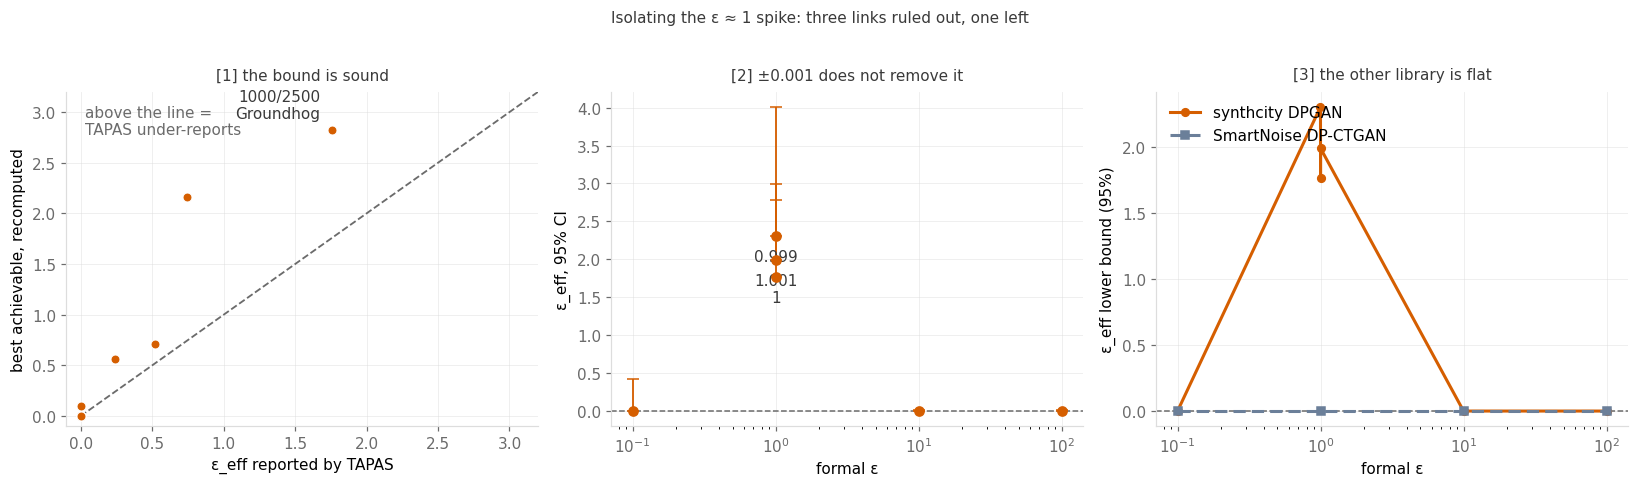

synthcity DPGAN, worst-case ε_eff by budget
   ε=0.1      0.000 [0.000, 0.423]
   ε=0.999    2.303 [2.303, 4.009]  <-- nudge
   ε=1        1.761 [1.761, 2.780]
   ε=1.001    1.989 [1.989, 2.993]  <-- nudge
   ε=10       0.000 [0.000, 0.009]
   ε=100      0.000 [0.000, 0.010]

SmartNoise DP-CTGAN, worst-case ε_eff by budget
   ε=0.1      0.000 [0.000, 0.008]
   ε=1        0.000 [0.000, 0.004]
   ε=10       0.000 [0.000, 0.010]
   ε=100      0.000 [0.000, 0.018]

[1] TAPAS exceeds the best achievable bound in 0 of 20 cells (0 = its arithmetic is sound)


In [18]:
# ---- three panels: what was ruled out, and what was not ----
DIAG = SPIKE_DIR
SN = "#6B7F99"          # SmartNoise, distinct from the repo's four-method palette

# [1] independent recomputation of the bound
rec = pd.read_csv(DIAG / "recomputed_eff_eps.csv") if (DIAG / "recomputed_eff_eps.csv").exists() else None

# [2] the eps nudge, plus the four original arms for context
def _worst(path, col="eps_low_95"):
    d = pd.read_csv(path)
    r = d.loc[d[col].idxmax()]
    return float(r[col]), float(r["eps_high_95"])

nudge = {}
for e in (0.999, 1.001):
    p = DIAG / "privacy" / f"eps{e:g}" / f"effeps_dpgan_eps{e:g}.csv"
    if p.exists():
        nudge[e] = _worst(p)
if EPS is not None:
    for _, r in EPS.dropna(subset=["worst_case_eff_eps_low"]).iterrows():
        nudge[float(r.formal_epsilon)] = (float(r.worst_case_eff_eps_low),
                                          float(r.worst_case_eff_eps_high))

# [3] SmartNoise DP-CTGAN
ctgan = {}
for e, d in sorted(DPC_ARMS.items()):
    p = d / "effeps_dpctgan_1000_2500.csv"
    if p.exists():
        ctgan[e] = _worst(p)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

# (a) [1] is TAPAS's bound attainable from the raw scores?
ax = axes[0]
if rec is not None:
    hi = max(rec.best_eps_low.max(), rec.tapas_eps_low.max()) * 1.1 + .1
    ax.plot([0, hi], [0, hi], color=MUTED, ls="--", lw=1.2, zorder=1)
    ax.scatter(rec.tapas_eps_low, rec.best_eps_low, s=34, color=ORANGE,
               edgecolor="white", lw=.6, zorder=3)
    top = rec.loc[rec.tapas_eps_low.idxmax()]
    ax.annotate(f"1000/2500\nGroundhog", (top.tapas_eps_low, top.best_eps_low),
                textcoords="offset points", xytext=(-8, 8), fontsize=10,
                color=INK, ha="right")
    ax.set_xlim(-.1, hi); ax.set_ylim(-.1, hi)
    ax.text(.04, .96, "above the line =\nTAPAS under-reports", transform=ax.transAxes,
            fontsize=10, color=MUTED, va="top")
ax.set_xlabel("ε_eff reported by TAPAS", fontsize=10)
ax.set_ylabel("best achievable, recomputed", fontsize=10)
ax.set_title("[1] the bound is sound", fontsize=10, color=INK, pad=8)

# (b) [2] does nudging eps off 1.0 remove the spike?
ax = axes[1]
if nudge:
    xs = sorted(nudge)
    lo = np.array([nudge[x][0] for x in xs])
    hi_ = np.array([nudge[x][1] for x in xs])
    near = [x for x in xs if 0.9 < x < 1.1]
    ax.errorbar(xs, lo, yerr=[np.zeros_like(lo), hi_ - lo], fmt="o", ms=6,
                color=ORANGE, capsize=4, elinewidth=1.2, zorder=3)
    for x in near:
        ax.annotate(f"{x:g}", (x, nudge[x][0]), textcoords="offset points",
                    xytext=(0, -16), fontsize=10, color=INK, ha="center")
    ax.set_xscale("log")
    ax.axhline(0, color=MUTED, ls="--", lw=1)
ax.set_xlabel("formal ε", fontsize=10)
ax.set_ylabel("ε_eff, 95% CI", fontsize=10)
ax.set_title("[2] ±0.001 does not remove it", fontsize=10, color=INK, pad=8)

# (c) [3] does another library's DP-SGD-on-CTGAN do the same?
ax = axes[2]
if nudge:
    xs = sorted(nudge)
    ax.plot(xs, [nudge[x][0] for x in xs], color=ORANGE, lw=2, marker="o", ms=5,
            label="synthcity DPGAN", zorder=3)
if ctgan:
    xs = sorted(ctgan)
    ax.plot(xs, [ctgan[x][0] for x in xs], color=SN, lw=2, marker="s", ms=5,
            ls=(0, (4, 2)), label="SmartNoise DP-CTGAN", zorder=3)
ax.axhline(0, color=MUTED, ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("formal ε", fontsize=10)
ax.set_ylabel("ε_eff lower bound (95%)", fontsize=10)
ax.set_title("[3] the other library is flat", fontsize=10, color=INK, pad=8)
ax.legend(frameon=False, fontsize=10, loc="upper left")

for a in axes:
    tidy(a); a.grid(color=GRID, lw=.6, alpha=.5)
fig.suptitle("Isolating the ε ≈ 1 spike: three links ruled out, one left",
             fontsize=10, color=INK, y=1.02)
fig.tight_layout()
fig.savefig(FIG_SUPP / "eps_spike_diagnosis.png", bbox_inches="tight")
plt.show()

# ---- the numbers behind the panels ----
if nudge:
    print("synthcity DPGAN, worst-case ε_eff by budget")
    for x in sorted(nudge):
        mark = "  <-- nudge" if x in (0.999, 1.001) else ""
        print(f"   ε={x:<7g} {nudge[x][0]:6.3f} [{nudge[x][0]:.3f}, {nudge[x][1]:.3f}]{mark}")
if ctgan:
    print("\nSmartNoise DP-CTGAN, worst-case ε_eff by budget")
    for x in sorted(ctgan):
        print(f"   ε={x:<7g} {ctgan[x][0]:6.3f} [{ctgan[x][0]:.3f}, {ctgan[x][1]:.3f}]")
if rec is not None:
    over = int((rec.tapas_exceeds_best > 1e-9).sum())
    print(f"\n[1] TAPAS exceeds the best achievable bound in {over} of {len(rec)} cells "
          f"(0 = its arithmetic is sound)")

In [19]:
# ---- the two tables behind section 6.3, one row per formal epsilon ----
# Same columns in both tables, so they read side by side. Two columns need a note
# because what they MEAN differs by library (see the printed note below):
#   eps_spent    synthcity solves backwards for sigma, so it hits formal_epsilon
#                exactly by construction -- eps_spent == formal_epsilon always.
#                SmartNoise fixes sigma and checks eps as a stopping rule, so
#                eps_spent is whatever the accountant had charged when it stopped,
#                which overshoots (or, at eps=100, undershoots) the target.
#   epochs_run   synthcity always completes DPGAN_N_ITER -- no early stopping exists
#                in that code path. SmartNoise stops the instant eps_spent crosses
#                formal_epsilon, so epochs_run varies arm to arm.
import json      # the setup cell does not import it; meta.json is read below
from config import DPGAN_N_ITER

COLS = ["formal_epsilon", "sigma", "eps_spent", "epochs_run", "epochs_cap",
        "eps_eff_low_95", "eps_eff_high_95", "attack"]

# Worst case = the largest certified lower bound across the 5 attacks, which is what
# EffectiveEpsilonReport reports for the mechanism. All arms audited at 1000/2500.

def _worst_row(path):
    """(eps_low_95, eps_high_95, attack) for the attack with the largest lower bound."""
    d = pd.read_csv(path)
    d["attack_short"] = d.attack.str.split("(").str[0]
    r = d.loc[d.eps_low_95.idxmax()]
    return float(r.eps_low_95), float(r.eps_high_95), str(r.attack_short)


# --- synthcity DPGAN: the four sweep arms plus the two nudges ---------------
rows = []
if EPS is not None:
    for _, r in EPS.iterrows():
        if pd.isna(r.get("worst_case_eff_eps_low")):
            continue
        e = float(r.formal_epsilon)
        rows.append({"formal_epsilon": e,
                     "sigma": float(r.sigma_audit) if "sigma_audit" in r else np.nan,
                     "eps_spent": e,              # solved backwards -> exact by construction
                     "epochs_run": DPGAN_N_ITER,  # always completes; no early stop
                     "epochs_cap": DPGAN_N_ITER,
                     "eps_eff_low_95": float(r.worst_case_eff_eps_low),
                     "eps_eff_high_95": float(r.worst_case_eff_eps_high),
                     "attack": str(r.worst_case_attack)})
for e in (0.999, 1.001):
    p = DIAG / "privacy" / f"eps{e:g}" / f"effeps_dpgan_eps{e:g}.csv"
    if p.exists():
        lo, hi, atk = _worst_row(p)
        rows.append({"formal_epsilon": e, "sigma": np.nan, "eps_spent": e,
                     "epochs_run": DPGAN_N_ITER, "epochs_cap": DPGAN_N_ITER,
                     "eps_eff_low_95": lo, "eps_eff_high_95": hi, "attack": atk})

DPGAN_TAB = (pd.DataFrame(rows)[COLS].sort_values("formal_epsilon").reset_index(drop=True)
             if rows else pd.DataFrame(columns=COLS))

# --- SmartNoise DP-CTGAN: budget requested vs budget actually spent ---------
# (eps actually spent, epochs run) as measured by run_dpctgan_audit.py --probe.
PROBE = {0.1: (0.9999577830784343, 2), 1.0: (1.473458489052405, 3),
         10.0: (10.066184821374424, 54), 100.0: (31.621294777570775, 300)}
rows = []
for e, d in sorted(DPC_ARMS.items()):
    p = d / "effeps_dpctgan_1000_2500.csv"
    if not p.exists():
        continue
    lo, hi, atk = _worst_row(p)
    meta = json.loads((d / "meta.json").read_text()) if (d / "meta.json").exists() else {}
    # meta.json carries these only for runs after the fix in run_dpctgan_audit.py
    # (it previously read them off a generator that never fitted on a resumed
    # process). PROBE holds the values measured directly by --probe; they are a
    # deterministic function of (eps, sigma, batch_size, n), identical every fit.
    rows.append({"formal_epsilon": e, "sigma": meta.get("sigma", 5),
                 "eps_spent": meta.get("last_epsilon_spent") or PROBE.get(e, (None, None))[0],
                 "epochs_run": meta.get("last_epochs_run") or PROBE.get(e, (None, None))[1],
                 "epochs_cap": meta.get("epochs_cap"),
                 "eps_eff_low_95": lo, "eps_eff_high_95": hi, "attack": atk})
CTGAN_TAB = (pd.DataFrame(rows)[COLS].sort_values("formal_epsilon").reset_index(drop=True)
             if rows else pd.DataFrame(columns=COLS))

fmt = lambda v: f"{v:.4f}"
print("synthcity DPGAN — effective epsilon at num_train/num_test = 1000/2500, worst case over 5 attacks\n")
print(DPGAN_TAB.to_string(index=False, float_format=fmt, na_rep="-"))
print("\n\nSmartNoise DP-CTGAN — same TAPAS threat model\n")
print(CTGAN_TAB.to_string(index=False, float_format=fmt, na_rep="-"))
print("\nNote: synthcity SOLVES for sigma to hit formal_epsilon exactly, so eps_spent")
print("== formal_epsilon and epochs_run is always the full DPGAN_N_ITER. SmartNoise")
print("FIXES sigma=5 and treats eps as a stopping rule checked once per epoch, so it")
print("overshoots (or at eps=100, undershoots by hitting the epoch cap first) and")
print("epochs_run varies. Requested eps and delivered eps are the same quantity in")
print("one library and not the other -- that difference is itself part of the finding.")

DPGAN_TAB.to_csv(DIAG / "effeps_by_epsilon_dpgan.csv", index=False)
CTGAN_TAB.to_csv(DPC_SWEEP / "effeps_by_epsilon_dpctgan.csv", index=False)

synthcity DPGAN — effective epsilon at num_train/num_test = 1000/2500, worst case over 5 attacks

 formal_epsilon   sigma  eps_spent  epochs_run  epochs_cap  eps_eff_low_95  eps_eff_high_95    attack
         0.1000 80.0000     0.1000          50          50          0.0000           0.4231 Groundhog
         0.9990       -     0.9990          50          50          2.3032           4.0091 Groundhog
         1.0000 11.7188     1.0000          50          50          1.7613           2.7802 Groundhog
         1.0010       -     1.0010          50          50          1.9893           2.9935 Groundhog
        10.0000  2.0142    10.0000          50          50          0.0000           0.0087 Groundhog
       100.0000  0.5273   100.0000          50          50          0.0000           0.0096 Groundhog


SmartNoise DP-CTGAN — same TAPAS threat model

 formal_epsilon  sigma  eps_spent  epochs_run  epochs_cap  eps_eff_low_95  eps_eff_high_95    attack
         0.1000      5     1.0000     

In [20]:
# ---- [1] the independent eff-eps recomputation, one row per (stage, attack) ----
REC_CSV = DIAG / "recomputed_eff_eps.csv"
if not REC_CSV.exists():
    print(f"not found: {REC_CSV.relative_to(BENCH)}\n"
          "  run: python benchmark_tapas/diagnostics/recompute_eff_eps.py")
else:
    REC_TAB = pd.read_csv(REC_CSV)
    show = ["stage", "attack", "n_scored", "tapas_eps_low", "best_eps_low",
            "best_tau", "best_branch", "tapas_exceeds_best"]
    print("Independent recomputation of eff-eps from TAPAS's own raw scores "
          "(DPGAN, formal eps=1.0)\n")
    print(REC_TAB[show].to_string(index=False, float_format=fmt))
    print("\nbest_eps_low = the largest eps_low_95 achievable at ANY threshold on these "
          "scores -- an upper envelope on whatever tau TAPAS's report picked.")
    print("tapas_exceeds_best > 0 would mean TAPAS reports a bound no threshold "
          "supports (a bug). Every value here is <= 0: TAPAS is sound, and where it "
          "differs from best_eps_low it is because it picks tau on a held-out split "
          "rather than optimising against the scores it reports -- conservative, "
          "not wrong.")

Independent recomputation of eff-eps from TAPAS's own raw scores (DPGAN, formal eps=1.0)

    stage                attack  n_scored  tapas_eps_low  best_eps_low  best_tau best_branch  tapas_exceeds_best
   50/100       ClosestDistance       100         0.0000        0.0000   -3.1685       TP/FP              0.0000
   50/100             Groundhog       100         0.0000        0.0000    0.3800       TP/FP              0.0000
   50/100    LocalNeighbourhood       100         0.0000        0.0000   -1.0000       TP/FP              0.0000
   50/100 ProbabilityEstimation       100         0.0000        0.0000  -89.0649       TP/FP              0.0000
   50/100       ShadowModelling       100         0.0000        0.0000    0.1300       TP/FP              0.0000
  200/500       ClosestDistance       500         0.0000        0.0000   -3.2109       TP/FP              0.0000
  200/500             Groundhog       500         0.5204        0.7147    0.4500       TN/FN             -0.1943
  200/

### 6.4 DP-CTGAN epoch-cap sweep — does more training leak more?

The spike diagnosis above swaps synthcity's DPGAN for SmartNoise's DP-CTGAN and finds the
same qualitative behaviour. This asks the follow-up: at a budget loose enough that the
**epoch cap** binds rather than the accountant, does training longer increase measured
leakage?

Run at ε = 100 with `epoch_cap` ∈ {300, 500, 750, 1000}, audit fixed at 1000/2500. ε = 100
is the point: at ε = 1.0 the accountant stops training after 3 epochs, so raising the cap
would change nothing. At ε = 100 all four caps ran their full length — 300, 500, 750 and
1000 epochs each — confirmed against `last_epochs_run` in each arm's `meta.json`.

**Read the confound, it is not removable.** SmartNoise fixes σ = 5, so privacy spend is a
function of the number of steps taken — each arm therefore differs in training length *and*
in realised ε simultaneously (300 → 31.6, 500 → 45.6, 750 → 61.7, 1000 → 76.7). Under this
parameterisation "does more training leak more?" and "does more spend leak more?" are the
same question. Panel (c) plots that relationship explicitly rather than hiding it.

**Answer: no, not measurably.** All four caps sit at or effectively at the Clopper–Pearson
floor — `eps_low_95` is 0.0000 at 300/750/1000 and 0.0112 at 500 (Groundhog, AUC 0.549), a
single point barely off the floor rather than a trend. There is no monotone relationship
between epoch cap (or the ε actually spent) and certified leakage across this range, even
though the spend itself grows by 2.4× from the shortest to the longest arm. Contrast this
with AIM in §7.1, where moving the budget by one order of magnitude (ε = 1 → 10) *does*
produce a large, certified jump — training length and privacy budget do not have symmetric
effects on measured leakage in these two mechanisms.


DP-CTGAN (SmartNoise) — epoch-cap sweep at formal eps=100, audit 1000/2500

 epoch_cap  epochs_run  eps_spent  eps_eff_low_95  eps_eff_high_95                attack  max_auc  max_advantage
       300         300    31.6213          0.0000           0.2537       ClosestDistance   0.5362         0.0440
       500         500    45.6037          0.0112           0.4229             Groundhog   0.5492         0.0776
       750         750    61.6743          0.0000           0.0178 ProbabilityEstimation   0.5247         0.0368
      1000        1000    76.6743          0.0000           0.0119             Groundhog   0.5289         0.0488


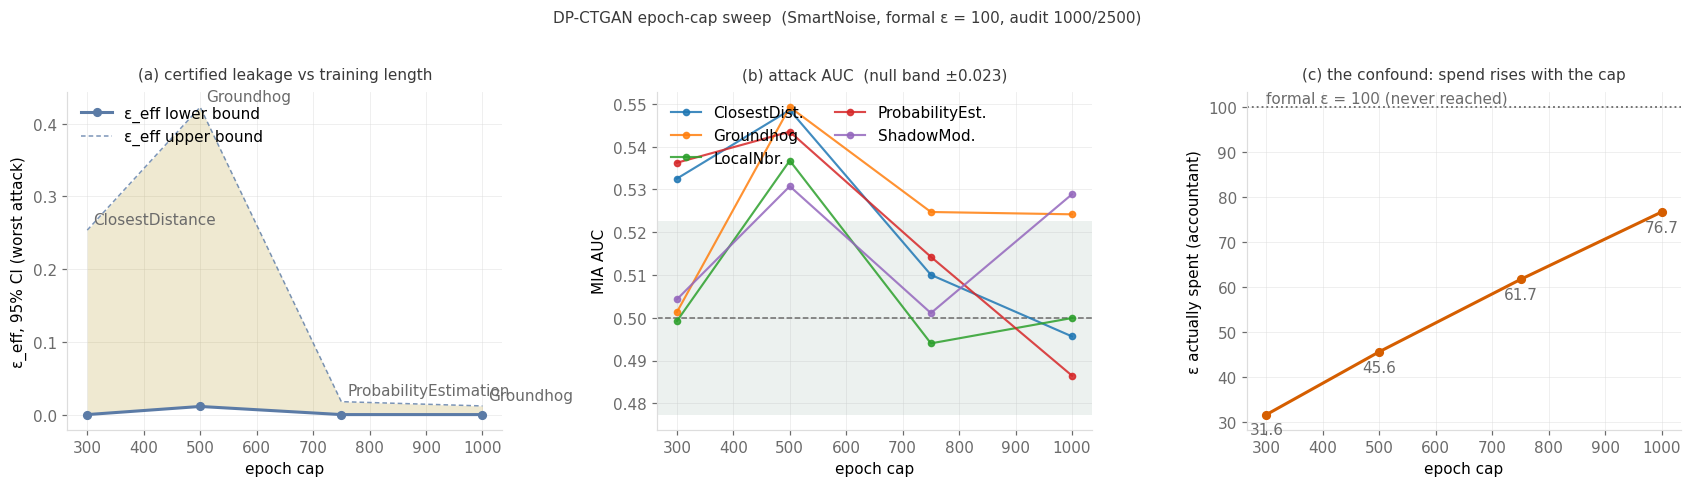

In [21]:
# ---- DP-CTGAN: effective epsilon against the epoch cap, eps=100, audit 1000/2500 ----
# cap=300 is the SmartNoise default and is the eps=100 arm of the eps sweep, so it lives
# at results/eps_sweep/dp_ctgan/eps100/; the other caps are under
# results/extras/dp_ctgan_epoch_cap/. Both are globbed, so
# this cell fills in as arms land rather than needing an edit.
EPOCH_STAGE = "1000_2500"
EPOCH_BASE = BENCH / "results" / "extras" / "dp_ctgan_epoch_cap"
EPOCH_300 = BENCH / "results" / "eps_sweep" / "dp_ctgan" / "eps100"

_arms = {}
_p300 = EPOCH_300 / EPOCH_STAGE / f"effeps_dpctgan_{EPOCH_STAGE}.csv"
if _p300.exists():
    _arms[300] = _p300.parent
for _d in sorted(EPOCH_BASE.glob("eps100_ep*")):
    _p = _d / EPOCH_STAGE / f"effeps_dpctgan_{EPOCH_STAGE}.csv"
    if _p.exists():
        _arms[int(_d.name.split("_ep")[1])] = _p.parent

if not _arms:
    print(f"no DP-CTGAN epoch arms found under {EPOCH_BASE.relative_to(BENCH)}/\n"
          "  run: python benchmark_tapas/audits/run_dpctgan_audit.py \\\n"
          "         --num-train 1000 --num-test 2500 --epsilon 100 --epoch-cap 500")
else:
    rows, per_attack = [], []
    for cap in sorted(_arms):
        d = pd.read_csv(_arms[cap] / f"effeps_dpctgan_{EPOCH_STAGE}.csv")
        d["attack_short"] = d.attack.str.split("(").str[0]
        d["epoch_cap"] = cap
        per_attack.append(d)
        meta = json.loads((_arms[cap] / "meta.json").read_text())
        # Same worst-case rule as the AIM table in section 7: the largest certified
        # lower bound, and when every bound sits at the floor, the widest interval --
        # i.e. the attack that is least ruled out.
        best = (d.loc[d.eps_high_95.idxmax()] if (d.eps_low_95 == 0).all()
                else d.loc[d.eps_low_95.idxmax()])
        rows.append({"epoch_cap": cap,
                     "epochs_run": meta.get("last_epochs_run"),
                     "eps_spent": meta.get("last_epsilon_spent"),
                     "eps_eff_low_95": float(best.eps_low_95),
                     "eps_eff_high_95": float(best.eps_high_95),
                     "attack": str(best.attack_short),
                     "max_auc": float(d.auc.max()),
                     "max_advantage": float(d.mia_advantage.max())})

    EPOCH_TAB = pd.DataFrame(rows)
    EATK = pd.concat(per_attack, ignore_index=True)
    print("DP-CTGAN (SmartNoise) — epoch-cap sweep at formal eps=100, audit 1000/2500\n")
    print(EPOCH_TAB.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    _missing = [c for c in (300, 500, 750, 1000) if c not in _arms]
    if _missing:
        print(f"\nstill running / not yet pulled: epoch_cap {_missing}")

    band = null_halfwidth(1250, 1250)
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
    caps = EPOCH_TAB.epoch_cap.values

    # (a) certified leakage. Flat at the floor = no attack certified any leakage.
    ax = axes[0]
    ax.fill_between(caps, EPOCH_TAB.eps_eff_low_95, EPOCH_TAB.eps_eff_high_95,
                    color=DPC_COLOR if "DPC_COLOR" in dir() else "#5B7BA6", alpha=.18, lw=0)
    ax.plot(caps, EPOCH_TAB.eps_eff_low_95, color="#5B7BA6", lw=2, marker="o", ms=5,
            label="ε_eff lower bound")
    ax.plot(caps, EPOCH_TAB.eps_eff_high_95, color="#5B7BA6", lw=1, ls=(0, (3, 2)),
            alpha=.8, label="ε_eff upper bound")
    for _, r in EPOCH_TAB.iterrows():
        ax.annotate(r.attack, (r.epoch_cap, r.eps_eff_high_95), textcoords="offset points",
                    xytext=(4, 4), fontsize=10, color=MUTED)
    ax.set_xlabel("epoch cap", fontsize=10)
    ax.set_ylabel("ε_eff, 95% CI (worst attack)", fontsize=10)
    ax.set_title("(a) certified leakage vs training length", fontsize=10, color=INK, pad=8)
    ax.legend(frameon=False, fontsize=10, loc="upper left")

    # (b) the raw signal, against the band a null would sit inside.
    ax = axes[1]
    ax.axhspan(0.5 - band, 0.5 + band, color=SAGE, alpha=.16, lw=0)
    ax.axhline(0.5, color=MUTED, ls="--", lw=1)
    for atk, g in EATK.groupby("attack_short"):
        g = g.sort_values("epoch_cap")
        ax.plot(g.epoch_cap, g.auc, lw=1.4, marker="o", ms=4, alpha=.85,
                label=SHORT_ATK.get(atk, atk))
    ax.set_xlabel("epoch cap", fontsize=10)
    ax.set_ylabel("MIA AUC", fontsize=10)
    ax.set_title(f"(b) attack AUC  (null band ±{band:.3f})", fontsize=10, color=INK, pad=8)
    ax.legend(frameon=False, fontsize=10, ncol=2, loc="upper left")

    # (c) the confound, stated rather than hidden: spend rises with the cap.
    ax = axes[2]
    if EPOCH_TAB.eps_spent.notna().any():
        e = EPOCH_TAB.dropna(subset=["eps_spent"])
        ax.plot(e.epoch_cap, e.eps_spent, color=ORANGE, lw=2, marker="o", ms=5)
        ax.axhline(100, color=MUTED, ls=":", lw=1.2)
        ax.text(e.epoch_cap.min(), 101, "formal ε = 100 (never reached)",
                fontsize=10, color=MUTED)
        for _, r in e.iterrows():
            ax.annotate(f"{r.eps_spent:.1f}", (r.epoch_cap, r.eps_spent),
                        textcoords="offset points", xytext=(0, -13), fontsize=10,
                        color=MUTED, ha="center")
    ax.set_xlabel("epoch cap", fontsize=10)
    ax.set_ylabel("ε actually spent (accountant)", fontsize=10)
    ax.set_title("(c) the confound: spend rises with the cap", fontsize=10, color=INK, pad=8)

    for a in axes:
        tidy(a); a.grid(color=GRID, lw=.6, alpha=.5)
    fig.suptitle("DP-CTGAN epoch-cap sweep  (SmartNoise, formal ε = 100, audit 1000/2500)",
                 fontsize=10, color=INK, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_SUPP / "dpctgan_epoch_sweep.png", bbox_inches="tight")
    plt.show()

    EPOCH_TAB.to_csv(EPOCH_BASE / "effeps_by_epoch_cap_dpctgan.csv",
                     index=False)


## 7. AIM — effective epsilon at every audit size

AIM is the one generator audited across **all four** num_train/num_test stages at a single
budget (ε = 1.0, δ = 1e-9), which is the mirror image of the DPGAN sweep in §6: that one
holds the audit size at 1000/2500 and varies ε instead.

Read from `results/sample_size_sweep/aim/{stage}/effeps_aim_{stage}.csv`, written by
`audits/run_aim_audit.py`. Same threat model as every other generator — same
fixed background, same target/alternate, same 5-attack battery, 500 records per simulation.

In [22]:
# ---- AIM: effective epsilon by audit size ----
AIM_RES = BENCH / "results" / "sample_size_sweep" / "aim"

rows, per_attack = [], []
for ntr, nte in STAGES:
    st = f"{ntr}_{nte}"
    p = AIM_RES / st / f"effeps_aim_{st}.csv"
    if not p.exists():
        continue
    d = pd.read_csv(p)
    d["attack_short"] = d.attack.str.split("(").str[0]
    d["stage"] = f"{ntr}/{nte}"
    per_attack.append(d)

    # Worst case = largest certified lower bound, which is what the report quotes for
    # the mechanism. Every AIM row sits at the floor, so the tie is broken by the
    # upper bound: report the attack whose interval is widest, i.e. the least ruled out.
    best = d.loc[d.eps_high_95.idxmax()] if (d.eps_low_95 == 0).all() else d.loc[d.eps_low_95.idxmax()]
    rows.append({"num_train": ntr, "num_test": nte,
                 "formal_epsilon": float(d.formal_epsilon.iloc[0]),
                 "delta": float(d.delta.iloc[0]) if "delta" in d else np.nan,
                 "eps_eff_low_95": float(best.eps_low_95),
                 "eps_eff_high_95": float(best.eps_high_95),
                 "attack": str(best.attack_short),
                 "max_auc": float(d.auc.max()),
                 "max_advantage": float(d.mia_advantage.max())})

if not rows:
    print(f"no AIM audit found under {AIM_RES.relative_to(BENCH)}/")
else:
    AIM_TAB = pd.DataFrame(rows)
    ATK = pd.concat(per_attack, ignore_index=True)
    f4 = lambda v: f"{v:.4f}"

    print("AIM (SmartNoise) — effective epsilon by audit size, eps=1.0 throughout\n")
    print(AIM_TAB.to_string(index=False, float_format=f4))

    # eps_low_95 is 0 in every cell, so the informative view is the UPPER bound:
    # it tightens as the audit grows, which is what a genuine null looks like.
    print("\n\neps_high_95 by attack x audit size  (lower = more tightly ruled out)\n")
    piv = (ATK.pivot_table(index="attack_short", columns="stage", values="eps_high_95")
           .reindex([a for a in ATTACK_ORDER if a in set(ATK.attack_short)])
           .reindex(columns=[f"{a}/{b}" for a, b in STAGES if f"{a}/{b}" in set(ATK.stage)]))
    print(piv.to_string(float_format=f4))

    print("\n\nMIA AUC by attack x audit size  (0.5 = chance)\n")
    print(ATK.pivot_table(index="attack_short", columns="stage", values="auc")
          .reindex(piv.index).reindex(columns=piv.columns).to_string(float_format=f4))

    n_nonzero = int((ATK.eps_low_95 > 0).sum())
    print(f"\neps_low_95 > 0 in {n_nonzero} of {len(ATK)} cells. Zero everywhere means no")
    print("attack certified any leakage at any audit size; the upper bound tightening")
    print(f"from {piv.max().max():.4f} to {piv.min().min():.4f} as the counts grow is the")
    print("signature of a genuine null rather than an underpowered measurement.")

    AIM_TAB.to_csv(AIM_RES / "effeps_by_stage_aim.csv", index=False)

AIM (SmartNoise) — effective epsilon by audit size, eps=1.0 throughout

 num_train  num_test  formal_epsilon  delta  eps_eff_low_95  eps_eff_high_95          attack  max_auc  max_advantage
        50       100          1.0000 0.0000          0.0000           0.3449 ShadowModelling   0.5464         0.0800
       200       500          1.0000 0.0000          0.0000           0.0580 ClosestDistance   0.5323         0.0280
       500      1000          1.0000 0.0000          0.0000           0.0243 ShadowModelling   0.5305         0.0480
      1000      2500          1.0000 0.0000          0.0000           0.0179 ClosestDistance   0.5321         0.0360


eps_high_95 by attack x audit size  (lower = more tightly ruled out)

stage                  50/100  200/500  500/1000  1000/2500
attack_short                                               
Groundhog              0.1019   0.0195    0.0213     0.0039
ShadowModelling        0.3449   0.0277    0.0243     0.0162
LocalNeighbourhood     0.1019  

### 7.1 AIM across the formal budget

The mirror of §6: hold the audit size at 1000/2500 and vary ε instead. Same axes and same
worst-case rule as the DPGAN sweep, so the two mechanisms can be read against each other —
DPGAN is overlaid where its sweep is available.

Unlike DP-CTGAN, AIM's ε is a genuine **calibration**: the (ε, δ) budget converts to ρ-zCDP
and the Gaussian noise is scaled so exactly that budget is spent over the 208 rounds. ε = 0.1
is a *noisier* AIM, not a shorter one, so these arms are comparable to each other in a way
the DP-CTGAN epoch arms are not.

**ε = 10 certifies real leakage — the only AIM arm that does.** ε = 0.1 and ε = 1.0 both sit
at the Clopper–Pearson floor (`eps_low_95 = 0`), but ε = 10 jumps to `eps_low_95 = 0.368`
`[0.368, 0.742]` via ShadowModelling, AUC 0.650, advantage 0.225. That is not floor noise:
the lower bound is more than 100× the width of the null band this audit size can express, and
it is certified, not just elevated AUC. Between ε = 1.0 (floor) and ε = 10 (certified
leakage) is where AIM's privacy-utility boundary sits for this threat model — a sharper
transition than DPGAN's, whose only above-floor point was the contested ε = 1.0 in §6.

**ε = 100 is absent, and deliberately so.** Audit cost scales inversely with the noise: less
noise lets AIM fit a richer graphical model, so Private-PGM inference and jax compilation
both blow up. Measured per-fit cost was 5.7 s at ε = 0.1, ~12 s at ε = 1.0, 26 s at ε = 10
and ~480 s at ε = 100 — the last needing ~19 days for 3500 fits. That is a reportable
computational finding in itself: auditing a weakly-private marginal generator costs far more
than auditing a strongly-private one, and it means the curve cannot be closed on this
hardware. Given ε = 10 already certifies leakage, that gap is a real limitation on the
claim, not a formality — ε = 100 would very plausibly show more, not less.


AIM (SmartNoise) — effective epsilon by formal budget, audit 1000/2500

 formal_epsilon  delta  eps_eff_low_95  eps_eff_high_95                attack  max_auc  max_advantage
         0.1000 0.0000          0.0000           0.0127 ProbabilityEstimation   0.5000         0.0008
         1.0000 0.0000          0.0000           0.0179       ClosestDistance   0.5321         0.0360
        10.0000 0.0000          0.3676           0.7421       ShadowModelling   0.6504         0.2248

not present: eps [100.0]  (eps=100 is computationally infeasible -- see the note above)


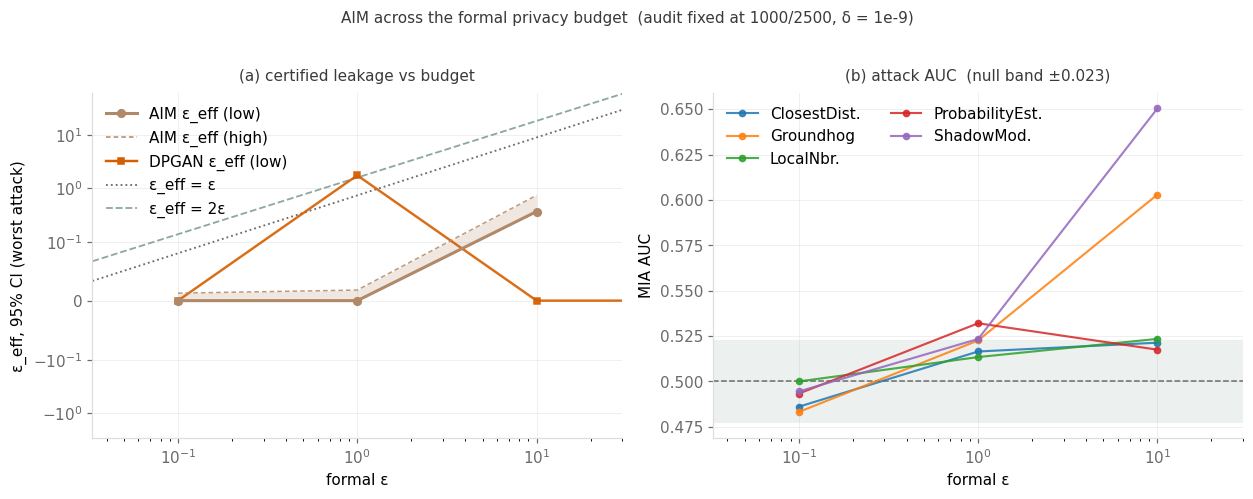

In [23]:
# ---- AIM: effective epsilon across the formal budget, audit fixed at 1000/2500 ----
# eps=1.0 lives at results/sample_size_sweep/aim/{stage}/; the other budgets are at
# results/eps_sweep/aim/eps{e}/{stage}/. Both are read, so this
# cell fills in as arms land rather than needing an edit.
AIM_STAGE = "1000_2500"
AIM_BASE = BENCH / "results" / "eps_sweep" / "aim"
AIM_ONE = BENCH / "results" / "sample_size_sweep" / "aim"

_eps_arms = {}
_p1 = AIM_ONE / AIM_STAGE / f"effeps_aim_{AIM_STAGE}.csv"
if _p1.exists():
    _eps_arms[1.0] = _p1.parent
for _d in sorted(AIM_BASE.glob("eps*")):
    _p = _d / AIM_STAGE / f"effeps_aim_{AIM_STAGE}.csv"
    if _d.is_dir() and _p.exists():
        _eps_arms[float(_d.name[3:])] = _p.parent

if not _eps_arms:
    print(f"no AIM eps arms found under {AIM_BASE.relative_to(BENCH)}/\n"
          "  run: python benchmark_tapas/audits/run_aim_audit.py \\\n"
          "         --num-train 1000 --num-test 2500 --epsilon 0.1")
else:
    rows, per_attack = [], []
    for e in sorted(_eps_arms):
        d = pd.read_csv(_eps_arms[e] / f"effeps_aim_{AIM_STAGE}.csv")
        d["attack_short"] = d.attack.str.split("(").str[0]
        d["formal_eps"] = e
        per_attack.append(d)
        best = (d.loc[d.eps_high_95.idxmax()] if (d.eps_low_95 == 0).all()
                else d.loc[d.eps_low_95.idxmax()])
        rows.append({"formal_epsilon": e,
                     "delta": float(d.delta.iloc[0]) if "delta" in d else np.nan,
                     "eps_eff_low_95": float(best.eps_low_95),
                     "eps_eff_high_95": float(best.eps_high_95),
                     "attack": str(best.attack_short),
                     "max_auc": float(d.auc.max()),
                     "max_advantage": float(d.mia_advantage.max())})

    AIM_EPS = pd.DataFrame(rows)
    AEATK = pd.concat(per_attack, ignore_index=True)
    print("AIM (SmartNoise) — effective epsilon by formal budget, audit 1000/2500\n")
    print(AIM_EPS.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    _miss = [e for e in (0.1, 1.0, 10.0, 100.0) if e not in _eps_arms]
    if _miss:
        print(f"\nnot present: eps {_miss}  "
              "(eps=100 is computationally infeasible -- see the note above)")

    band = null_halfwidth(1250, 1250)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    xs = AIM_EPS.formal_epsilon.values
    lo, hi = xs.min() / 3, xs.max() * 3

    # (a) certified leakage vs the budget paid for -- same construction as section 6(a),
    #     with DPGAN overlaid so the two mechanisms sit on one pair of axes.
    ax = axes[0]
    ax.plot([lo, hi], [lo, hi], color=MUTED, ls=":", lw=1.2, zorder=1)
    ax.plot([lo, hi], [2 * lo, 2 * hi], color=SAGE, ls="--", lw=1.2, zorder=1)
    ax.fill_between(xs, AIM_EPS.eps_eff_low_95, AIM_EPS.eps_eff_high_95,
                    color="#B08968", alpha=.20, lw=0)
    ax.plot(xs, AIM_EPS.eps_eff_low_95, color="#B08968", lw=2, marker="o", ms=5, zorder=3)
    ax.plot(xs, AIM_EPS.eps_eff_high_95, color="#B08968", lw=1, ls=(0, (3, 2)),
            alpha=.85, zorder=3)
    handles = [Line2D([], [], color="#B08968", lw=2, marker="o", ms=5, label="AIM ε_eff (low)"),
               Line2D([], [], color="#B08968", lw=1, ls=(0, (3, 2)), label="AIM ε_eff (high)"),
               Line2D([], [], color=MUTED, ls=":", lw=1.2, label="ε_eff = ε"),
               Line2D([], [], color=SAGE, ls="--", lw=1.2, label="ε_eff = 2ε")]
    _dpgan = globals().get("EPS")
    if _dpgan is not None and "worst_case_eff_eps_low" in _dpgan:
        h = _dpgan.dropna(subset=["worst_case_eff_eps_low"])
        if len(h):
            ax.plot(h.formal_epsilon, h.worst_case_eff_eps_low, color=ORANGE, lw=1.6,
                    marker="s", ms=4.5, alpha=.9, zorder=2)
            handles.insert(2, Line2D([], [], color=ORANGE, lw=1.6, marker="s", ms=4.5,
                                     label="DPGAN ε_eff (low)"))
    ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=0.1); ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε", fontsize=10)
    ax.set_ylabel("ε_eff, 95% CI (worst attack)", fontsize=10)
    ax.set_title("(a) certified leakage vs budget", fontsize=10, color=INK, pad=8)
    ax.legend(handles=handles, frameon=False, fontsize=10, loc="upper left")

    # (b) the raw signal per attack. A genuine null stays inside the band at every eps.
    ax = axes[1]
    ax.axhspan(0.5 - band, 0.5 + band, color=SAGE, alpha=.16, lw=0)
    ax.axhline(0.5, color=MUTED, ls="--", lw=1)
    for atk, g in AEATK.groupby("attack_short"):
        g = g.sort_values("formal_eps")
        ax.plot(g.formal_eps, g.auc, lw=1.4, marker="o", ms=4, alpha=.85,
                label=SHORT_ATK.get(atk, atk))
    ax.set_xscale("log"); ax.set_xlim(lo, hi)
    ax.set_xlabel("formal ε", fontsize=10)
    ax.set_ylabel("MIA AUC", fontsize=10)
    ax.set_title(f"(b) attack AUC  (null band ±{band:.3f})", fontsize=10, color=INK, pad=8)
    ax.legend(frameon=False, fontsize=10, ncol=2, loc="upper left")

    for a in axes:
        tidy(a); a.grid(color=GRID, lw=.6, alpha=.5)
    fig.suptitle("AIM across the formal privacy budget  (audit fixed at 1000/2500, δ = 1e-9)",
                 fontsize=10, color=INK, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_SUPP / "eps_sweep_aim.png", bbox_inches="tight")
    plt.show()

    AIM_EPS.to_csv(AIM_BASE / "effeps_by_formal_eps_aim.csv", index=False)


### 7.2 AIM side by side with Chida et al.

The same two figures as §6.1 — Chida et al.'s **Table 1** and **Fig. 4**, in their layout
and row/panel order (ε = 100 → 0.1) — rebuilt on AIM. Same functions, same worst-case rule,
same Clopper–Pearson floor, so the three generators can be read against each other and
against Chida's own numbers without any adjustment.

AIM is the closest of the three to Chida's setting: like their generator it is
**marginal-based**, and unlike DP-CTGAN its ε is a genuine calibration rather than a
stopping rule, so a row labelled ε = 0.1 really was generated under a budget of 0.1. That
makes it the fairest row-for-row comparison with their table; DP-CTGAN's rows have to be
read against the ε its accountant actually spent.

**This table is where the certified-leakage finding from §7.1 is visible next to Chida's own
numbers.** ε = 1.0 and ε = 0.1 sit on the same floor Chida's PrivBayes rows do
(`0 / ~0.0039–0.0057`). ε = 10 does not: `0.368 / 0.742` at 95%, with ShadowModelling setting
the bound rather than the usual Groundhog. Chida's table has no row that leaves the floor
this decisively at a budget this loose — their closest comparator, PrivBayes at ε = 1, is
already at the floor by ε = 100 and 10 both. This is the one row in this notebook's three
Chida-style tables (§6.1, here) where the certified lower bound is unambiguous rather than
zero.

ε = 100 is not attempted — at ~480 s/fit it needs ~19 days for 3500 fits, because low noise
lets AIM fit a much richer graphical model. See §7.1.


In [24]:
# ---- Chida Table 1 equivalent, for AIM ----
# Same chida_table() as section 6.1. AIM's eps=1.0 arm lives in sample_size_sweep/aim/
# rather than eps_sweep/aim/eps1/, so it is passed in explicitly via `extra` rather
# than discovered by the glob.
AIM_RES = BENCH / "results" / "sample_size_sweep" / "aim"
AIM_EPS = BENCH / "results" / "eps_sweep" / "aim"
_aim_eps1 = AIM_RES / "1000_2500"
AIM_ARMS = chida_arms(
    AIM_EPS, "aim", nested=True,
    extra={1.0: _aim_eps1} if (_aim_eps1 / "effeps_aim_1000_2500.csv").exists() else None)

AIM_CHIDA_TAB = chida_table(AIM_ARMS, "aim", "AIM, SmartNoise",
                            out_csv=AIM_EPS / "effeps_by_confidence_aim.csv")
if AIM_ARMS:
    _missing = [e for e in (0.1, 1.0, 10.0, 100.0) if e not in AIM_ARMS]
    if _missing:
        print(f"\narms not present: eps {_missing}")
        print("  eps=100 is computationally infeasible (see 7.1).")

    if 10.0 in AIM_ARMS and AIM_CHIDA_TAB is not None and 10.0 in AIM_CHIDA_TAB.index:
        row10 = AIM_CHIDA_TAB.loc[10.0]
        if row10["0.95 (low)"] > 0:
            print(f"\neps=10 certifies real leakage: {row10['0.95 (low)']:.4f} / "
                  f"{row10['0.95 (high)']:.4f} at 95% via {row10['attack']} -- the only "
                  f"AIM arm above the floor. See section 7.1.")
    print("\nAIM's delta is 1e-9 at every budget, and its epsilon is a true calibration:")
    print("the (eps, delta) pair converts to rho-zCDP and the Gaussian noise is scaled so")
    print("exactly that budget is spent over the 208 rounds. So unlike DP-CTGAN in 6.1,")
    print("the index of this table is the budget that was actually paid.")


Effective epsilon (AIM, SmartNoise), worst case over the 5 attacks

      0.90 (low)  0.90 (high)  0.95 (low)  0.95 (high)  0.99 (low)  0.99 (high)
eps                                                                            
10.0    0.390492     0.718594    0.367587     0.742081    0.321642     0.789425
1.0            0     0.003256           0     0.003884           0     0.005324
0.1            0     0.004932           0     0.005663           0     0.007301

attack setting the bound: eps=10 -> ShadowModelling, eps=1 -> Groundhog, eps=0.1 -> Groundhog

rows at the certified floor (eps_low = 0): eps=1, eps=0.1
  their 95% upper bounds span 0.003884 to 0.005663

arms not present: eps [100.0]
  eps=100 is computationally infeasible (see 7.1).

eps=10 certifies real leakage: 0.3676 / 0.7421 at 95% via ShadowModelling -- the only AIM arm above the floor. See section 7.1.

AIM's delta is 1e-9 at every budget, and its epsilon is a true calibration:
the (eps, delta) pair converts to rho-z

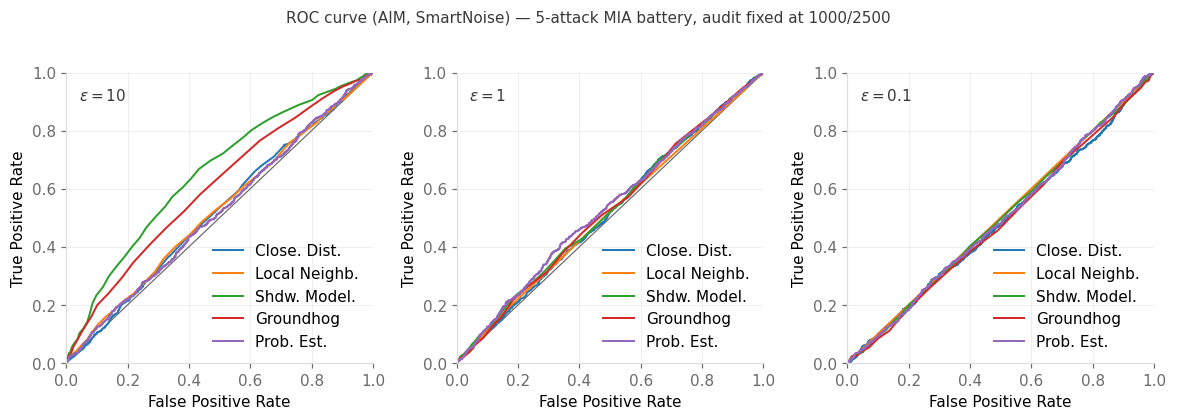

In [25]:
# ---- Chida Fig 4 equivalent, for AIM ----
chida_roc(AIM_ARMS, "aim", "AIM, SmartNoise",
          FIG_SUPP / "eps_sweep_roc_aim.png")


## 8. Combined view — fidelity, utility, privacy and cost

One radar per generator family question: is there a generator that is good at everything?
All five are at formal eps = 1.0. synthcity's DPGAN is excluded, as in sections 1-5.

**Why seven spokes and not four.** Fidelity is four SDMetrics scores, and averaging them
destroys the most interesting thing in the table: AIM has the best marginals of any
generator (KS 0.913, TV 0.988) and the *worst* correlation similarity (0.784), because it
spends its budget on low-order marginals and never models the continuous-continuous
structure. CTGAN is the mirror image. A single "fidelity" mean would show both as
mid-table and hide the trade. The four stay separate, adjacent, so the fidelity lobe is
still readable as one region.

**Normalisation.** The four families are not commensurable -- fidelity and retention sit
in [0.36, 0.99], mean MIA advantage spans 54x, wall clock 14x -- so each spoke is
min-max scaled across these five generators and oriented so outward is better. That makes
the chart a *ranking among these five*, not an absolute score: adding a sixth generator
would rescale every spoke. The raw worst -> best range is printed at each label so a real
number is always recoverable, and the raw table is printed below the figures.

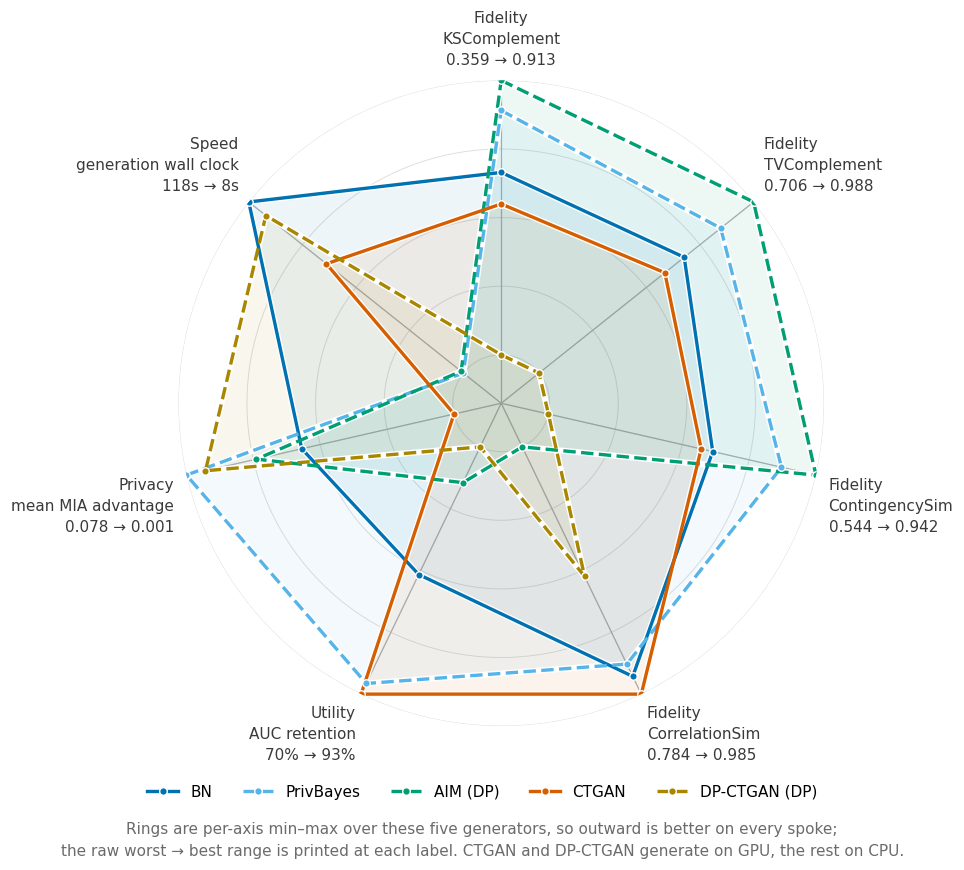

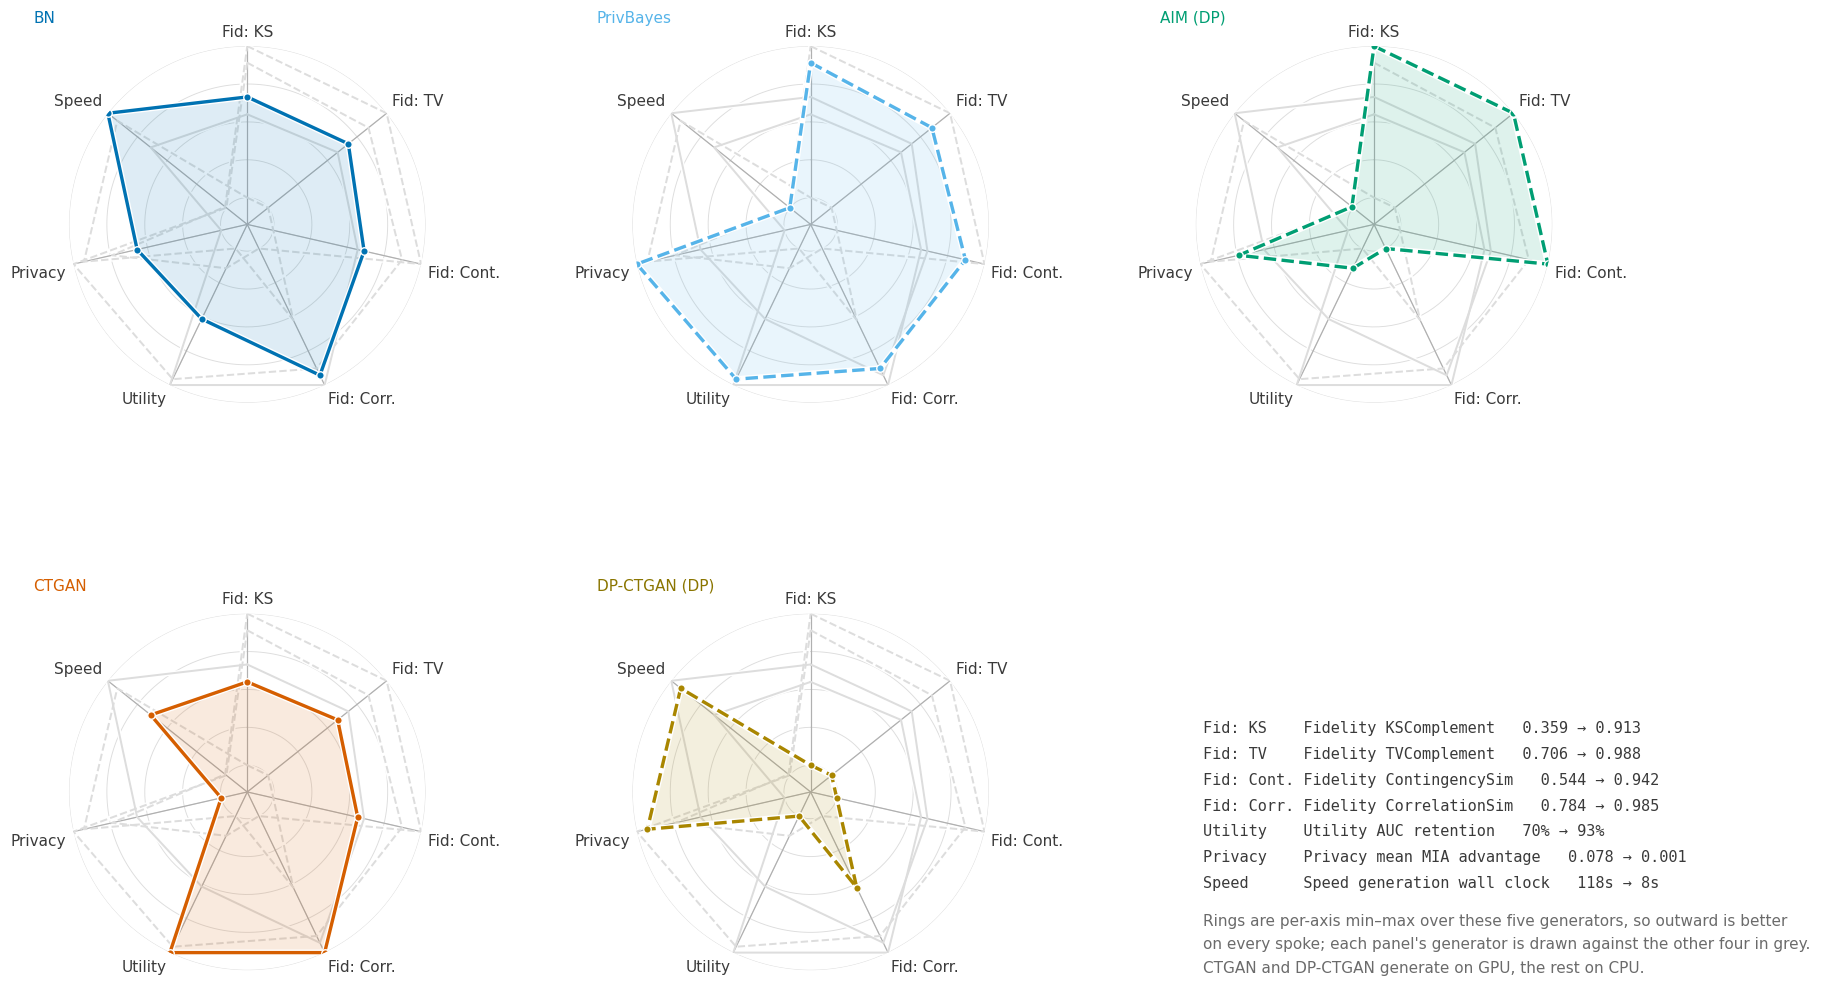

raw values (formal eps = 1.0, privacy from the 1000/2500 audit)

                      KS      TV    Cont    Corr  Retention  MIA adv.  Gen (s)
method                                                                        
bayesian_network  0.7274  0.8966  0.7889  0.9702     0.8188    0.0344    8.240
privbayes         0.8524  0.9445  0.8911  0.9602     0.9202    0.0014  117.538
aim               0.9131  0.9876  0.9425  0.7839     0.7333    0.0214  116.396
ctgan             0.6638  0.8713  0.7717  0.9846     0.9301    0.0779   47.750
dpctgan           0.3591  0.7064  0.5445  0.8890     0.7000    0.0069   16.910

device: {'bayesian_network': 'cpu', 'privbayes': 'cpu', 'aim': 'cpu', 'ctgan': 'cuda', 'dpctgan': 'cuda'}


In [26]:
# ---- section 8: combined radar ----
# Reads the three result tables the other notebooks own (fidelity, utility, cost) and
# takes privacy from METRICS, which sections 1-5 already built.
from config import FIDELITY_RESULTS, REPO_ROOT

_stage = f"{AVAIL[-1][0]}_{AVAIL[-1][1]}"
_fid = pd.read_csv(FIDELITY_RESULTS).set_index("method")
_ut = pd.read_csv(UTILITY_RESULTS).set_index("method")
_adv = METRICS[_stage].groupby("method").mia_advantage.mean()

# aim/dpctgan generation time comes from the SmartNoise table, not computational_cost.csv:
# eval_utility/eval_fidelity read those two generators from
# synthetic_data/smartnoise/{m}/eps1/, so the cost belonging beside their fidelity and
# utility rows is the one logged when THOSE draws were written. computational_cost.csv
# also carries an aim generation row (99.2 s, from the earlier generate_runs.py pass);
# using it would price a different draw than the one scored here.
_c = pd.read_csv(REPO_ROOT / "evaluation" / "results" / "computational_cost.csv")
_c = _c[(_c.stage == "generation") & (~_c.method.isin(["aim", "dpctgan"]))]
_s = pd.read_csv(REPO_ROOT / "evaluation" / "results" / "smartnoise" / "generation_cost.csv")
_s = _s[(_s.stage == "generation") & (_s.formal_epsilon == 1.0)]
_cost = pd.concat([_c, _s])

RAW = pd.DataFrame({
    "KS": _fid.KSComplement_mean, "TV": _fid.TVComplement_mean,
    "Cont": _fid.ContingencySimilarity_mean, "Corr": _fid.CorrelationSimilarity_mean,
    "Retention": _ut.retention_xgboost_mean, "MIA adv.": _adv,
    "Gen (s)": _cost.groupby("method").wall_clock_s.mean(),
}).loc[GENS]

_p3 = lambda x: f"{x:.3f}"
AXES = [                        # (column, long label, short label, formatter, higher_better)
    ("KS",        "Fidelity\nKSComplement",       "Fid: KS",    _p3, True),
    ("TV",        "Fidelity\nTVComplement",       "Fid: TV",    _p3, True),
    ("Cont",      "Fidelity\nContingencySim",     "Fid: Cont.", _p3, True),
    ("Corr",      "Fidelity\nCorrelationSim",     "Fid: Corr.", _p3, True),
    ("Retention", "Utility\nAUC retention",       "Utility",
     lambda x: f"{100 * x:.0f}%", True),
    ("MIA adv.",  "Privacy\nmean MIA advantage",  "Privacy",    _p3, False),
    ("Gen (s)",   "Speed\ngeneration wall clock", "Speed",
     lambda x: f"{x:.0f}s", False),
]
RLO, RHI = .15, 1.0   # ring range: worst sits on RLO, not at the centre, so a worst-in-
                      # class score still draws a visible vertex rather than collapsing


def _norm(col, better_high):
    v = RAW[col].astype(float)
    u = (v - v.min()) / (v.max() - v.min())      # 0 = worst raw, 1 = best raw
    return RLO + (u if better_high else 1 - u) * (RHI - RLO)


N = pd.DataFrame({c: _norm(c, hb) for c, _, _, _, hb in AXES})
ANG = np.linspace(0, 2 * np.pi, len(AXES), endpoint=False)
CLOSED = np.concatenate([ANG, ANG[:1]])
_ring = np.linspace(0, 2 * np.pi, 200)
TITLE_INK = {"dpctgan": "#8A7500"}   # Okabe-Ito yellow is unreadable as text on white


def radar_frame(ax, labels="long", labsize=10):
    """Rings, spokes and spoke labels.

    labels="long" prints metric + raw range at each spoke (for a single chart);
    "short" prints just a tag, because repeating one identical range key across five
    small multiples crowds neighbouring panels and says nothing new -- there the key
    goes in the grid's empty cell instead.
    """
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
    ax.set_ylim(0, 1.0); ax.set_yticks([]); ax.set_yticklabels([])
    ax.set_xticks(ANG); ax.set_xticklabels([])
    ax.spines["polar"].set_visible(False)
    for r in (RLO, .3625, .575, .7875, RHI):
        ax.plot(_ring, [r] * 200, color=GRID, lw=.6, zorder=0)
    for a in ANG:
        ax.plot([a, a], [0, RHI], color=GRID, lw=.6, zorder=0)
    # Label and raw range are ONE text block so they cannot drift apart and overlap.
    # Alignment comes from the spoke's screen direction (theta_offset=pi/2 with
    # direction=-1 puts a spoke at x=sin(a), y=cos(a)), so a label always sits outside
    # the ring on the correct side rather than across the plot.
    for a, (c, lab, short, fmt, hb) in zip(ANG, AXES):
        lo, hi = RAW[c].min(), RAW[c].max()
        worst, best = (lo, hi) if hb else (hi, lo)
        sx, sy = np.sin(a), np.cos(a)
        ha = "left" if sx > .15 else ("right" if sx < -.15 else "center")
        va = "bottom" if sy > .15 else ("top" if sy < -.15 else "center")
        ax.text(a, 1.04, f"{lab}\n{fmt(worst)} → {fmt(best)}" if labels == "long" else short,
                ha=ha, va=va, fontsize=labsize, color=INK, linespacing=1.5)


def radar_draw(ax, g, color=None, lw=2.2, fill=.07, dots=True, zorder=4):
    v = np.concatenate([N.loc[g].values, N.loc[g].values[:1]])
    col = color or GEN_COLOR[g]
    # A white underlay keeps the pale series (Okabe-Ito yellow especially) readable
    # where polygons cross; without it the yellow all but vanishes against white.
    ax.plot(CLOSED, v, color="white", lw=lw + 1.8, zorder=zorder - 1, solid_capstyle="round")
    ax.plot(CLOSED, v, color=col, lw=lw, ls="--" if GEN_DP[g] else "-",
            zorder=zorder, solid_capstyle="round")
    if fill:
        ax.fill(CLOSED, v, color=col, alpha=fill, zorder=zorder - 2)
    if dots:
        ax.scatter(ANG, N.loc[g].values, s=24, color=col, zorder=zorder + 1,
                   edgecolor="white", lw=.9)


_handles = [Line2D([], [], color=GEN_COLOR[g], lw=2.2, ls="--" if GEN_DP[g] else "-",
                   marker="o", markersize=5, markeredgecolor="white", markeredgewidth=.9,
                   label=LABELS[g]) for g in GENS]

# ---- A: all five overlaid ----
fig, ax = plt.subplots(figsize=(9.2, 7.8), subplot_kw={"projection": "polar"})
radar_frame(ax)
for g in GENS:
    radar_draw(ax, g)
fig.legend(handles=_handles, loc="lower center", ncol=5, frameon=False, fontsize=10,
           bbox_to_anchor=(.5, .045))
fig.text(.5, -.005, "Rings are per-axis min–max over these five generators, so outward is "
         "better on every spoke;\nthe raw worst → best range is printed at each label. "
         "CTGAN and DP-CTGAN generate on GPU, the rest on CPU.",
         ha="center", fontsize=10, color=MUTED, linespacing=1.6)
fig.tight_layout(rect=[0, .085, 1, 1])
fig.savefig(FIG_SUPP / "radar_combined.png", bbox_inches="tight")
plt.show()

# ---- B: small multiples, each generator against the other four in grey ----
fig, axes = plt.subplots(2, 3, figsize=(14.5, 10.6), subplot_kw={"projection": "polar"})
for i, g in enumerate(GENS):
    ax = axes[i // 3][i % 3]
    radar_frame(ax, labels="short", labsize=10)
    for other in GENS:
        if other != g:
            radar_draw(ax, other, color=GRID, lw=1.3, fill=0, dots=False, zorder=2)
    radar_draw(ax, g, fill=.13)
    # Title goes in the panel's top-left CORNER, in axes coordinates: a circular plot
    # never reaches the corners of its bounding box, so that space is always free --
    # whereas set_title sits directly above the topmost spoke label and collides with it.
    ax.text(-.10, 1.10, LABELS[g], transform=ax.transAxes, ha="left", va="top",
            fontsize=10, color=TITLE_INK.get(g, GEN_COLOR[g]))
axes[1][2].set_axis_off()
axes[1][2].text(.02, .70, "\n".join(
    f"{short:<11}{lab.replace(chr(10), ' ')}   "
    f"{fmt(RAW[c].min() if hb else RAW[c].max())} → {fmt(RAW[c].max() if hb else RAW[c].min())}"
    for c, lab, short, fmt, hb in AXES),
    transform=axes[1][2].transAxes, ha="left", va="top", fontsize=10, color=INK,
    linespacing=1.9, family="monospace")
axes[1][2].text(.02, .16,
    "Rings are per-axis min–max over these five generators, so outward is better\n"
    "on every spoke; each panel's generator is drawn against the other four in grey.\n"
    "CTGAN and DP-CTGAN generate on GPU, the rest on CPU.",
    transform=axes[1][2].transAxes, ha="left", va="top", fontsize=10, color=MUTED,
    linespacing=1.7)
fig.subplots_adjust(left=.04, right=.97, top=.90, bottom=.05, wspace=.58, hspace=.34)
fig.savefig(FIG_SUPP / "radar_small_multiples.png", bbox_inches="tight")
plt.show()

print("raw values (formal eps = 1.0, privacy from the "
      f"{AVAIL[-1][0]}/{AVAIL[-1][1]} audit)\n")
print(RAW.round(4).to_string())
print("\ndevice:", dict(_cost.groupby("method").device.first()[GENS]))
